## This Notebook gives an example on how to plot all cell types, how to quantify cell types using equal width columns, and how to quantify cell types by layer (Figure 2 and Supplementary Figures 6-7 in the manuscript)

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import napari
from shapely import Polygon,Point
import seaborn as sns
from adjustText import adjust_text
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr, spearmanr
import scipy.stats as stats
from scipy.spatial import KDTree
from scipy.stats import sem

In [2]:
adata_all=sc.read_h5ad('../W_Data_Short/adata_short_all.h5ad')

### Choose same width columns:

In [3]:
X=adata_all.obsm["X_spatial"]

In [4]:
cmap = [ '#800000','#800000',  #Astro  P, WM
    '#4363d8', '#bfef45', #L2, L3, 
    '#42d4f4', # L4 
    '#f58231',  #L5
    '#008080','#e6194B',  '#ffe119', '#e6beff', '#e6194B', '#f032e6', '#911eb4', # L6,L6Car3,  L6CT, L6b, # L5ET, L56NP,
]

In [5]:
##Excitatory neurons 
cell_types_plot =  ['Astro.WM','Astro.P','L2.IT', 'L3.IT', 'L4.IT', 'L5.6.NP', 'L5.ET', 'L5.IT', 'L6.CT', 'L6.IT', 'L6.IT.Car3', 'L6b']
colors = [cmap[cell_types_plot.index(nm)%len(cmap)] if nm in cell_types_plot else "gray" 
 for nm in adata_all.obs["cluster_names"]]
size = [50 if nm in cell_types_plot else 10
 for nm in adata_all.obs["cluster_names"]]
V = napari.view_points(X,face_color=colors,size=size)

In [6]:
##Draw shape in interface and save coordinates  
paths = V.layers[-1].data

In [6]:
##Projection
H1_path = [[19153.5489573113, 774.8946785515946],
  [21469.0832103889, -1011.3994592523427],
  [20779.438495011244, -1905.370906101668],
  [18463.90424193364, -119.07676829773277]]
H2_path_1 = [[20088.48971740354, 5347.519518327886],
  [17716.773644550052, 8225.725930272227],
  [18588.123204084128, 8943.740363504616],
  [20959.83927693758, 6065.533951560273]]
H2_path_2= [[21213.14658678075, 6331.528863252207],
  [18428.558212399854, 8794.830110147508],
  [19176.65121521971, 9640.496498484043],
  [21961.23958960058, 7177.195251588745]]
H3_path_1 = [[17564.16201780671, 13032.652234493276],
  [20395.88896313461, 14227.551789266368],
  [20834.84086468564, 13187.303737427314],
  [18003.113919357744, 11992.404182654214]]
H3_path_2 =  [[16412.610972909293, 17577.393349625145],
  [19462.99880461167, 17953.68647352598],
  [19601.231829969754, 16833.112329646792],
  [16550.84399826738, 16456.819205745953]]
H3_path_3 = [[16533.945717294817, 15939.293326058607],
  [19543.77793804265, 16561.68584034619],
  [19772.416717989618, 15456.009988419159],
  [16762.584497241784, 14833.617474131564]]
H3_path_4 = [[17068.620872475774, 14113.090005595543],
  [19908.762512580488, 15287.848662953003],
  [20340.3155618752, 14244.509433903002],
  [17500.173921770485, 13069.750776545532]]
H5_path_1 = [[19388.516476123117, 34296.61458503952],
  [18460.462140414602, 30484.96565611136],
  [17363.442525287002, 30752.066283694927],
  [18291.496860995554, 34563.71521262312]]
H5_path_2 = [[22787.32013179405, 30894.74769646524],
  [19208.745930088648, 29287.340128262622],
  [18746.122625549597, 30317.27918438564],
  [22324.696827255048, 31924.686752588274]]
H6_path_1 = [[28870.8875018958, -3549.3246012883146],
  [27804.78933826677, -266.20621891356586],
  [28878.659542144513, 82.5022072160973],
  [29944.75770577351, -3200.6161751587542]]
H6_path_2 = [[31805.863123401115, 1497.8961670561155],
  [28355.282679905944, 1592.3747897651638],
  [28386.18555148821, 2721.019903943332],
  [31836.765994983423, 2626.5412812342242]]
H6_path_3 =  [[31700.110874583264, -214.68056379385018],
  [28558.118340679335, -476.9885737737402],
  [28464.185309908702, 648.1653565666923],
  [31606.177843812708, 910.473366546511]]
H6_path_4 =[[26654.75291066144, -3184.858015133872],
  [27563.009180102756, 145.38254017151348],
  [28652.29250252985, -151.69762529307647],
  [27744.03623308845, -3481.938180598524]]
H7_path_1 = [[26482.81962395221, 5263.265728376346],
  [27572.588219432226, 9872.400150832711],
  [28671.36194595592, 9612.609698484093],
  [27581.593350475858, 5003.475276027683]]
H7_path_2 =  [[31744.80359372502, 6791.0845787575645],
  [28817.974624378792, 9484.75722530951],
  [29582.569739199396, 10315.533423586014],
  [32509.39870854565, 7621.860777033947]]
H8_path_1 = [[31842.470513538778, 13822.605601817173],
  [29026.449934068678, 14270.806679994308],
  [29203.919914927617, 15385.839947266715],
  [32019.94049439777, 14937.638869089515]]
H8_path_2 = [[27038.26722384071, 17447.631762891837],
  [29318.03758647336, 16268.803481001094],
  [28799.44391032349, 15265.88006404068],
  [26519.673547690836, 16444.7083459315]]
H8_path_3 = [[31310.382664815563, 18282.000723243727],
  [29670.07052812814, 15320.644937933263],
  [28682.396480748277, 15867.723321131258],
  [30322.708617435776, 18829.07910644172]]
H8_path_4 = [[27703.15123303357, 19263.8123103695],
  [29796.895191318177, 16233.15467232711],
  [28867.952962554795, 15591.390605983126],
  [26774.209004270208, 18622.048244025576]]
H9_path_1 = [[30806.355761634048, 21444.664516388453],
  [27143.631263215422, 24987.706779868306],
  [27928.634368184037, 25799.22690064157],
  [31591.35886660269, 22256.18463716166]]
H9_path_2 =  [[26843.443583610486, 20656.581354911596],
  [27006.390195102595, 25380.080755737094],
  [28134.78707678765, 25341.154432589483],
  [27971.840465295427, 20617.65503176386]]
H9_path_3 =  [[29272.828312162026, 20845.546845505953],
  [26935.835949510656, 25246.63622710948],
  [27933.035707349165, 25776.152444233285],
  [30270.028070000517, 21375.063062629695]]
C4_path_1 = [[-2388.2664816377387, 34329.209790127876],
  [1202.6863002803268, 30958.23275531709],
  [432.26962082951786, 30137.541931932275],
  [-3158.6831610885997, 33508.51896674309]]
C4_path_2 =  [[736.4669166025333, 34384.05182869643],
  [1869.7440271306796, 31620.764122534234],
  [828.2829609967546, 31193.64103103572],
  [-304.9941495314247, 33956.928737197915]]
C5_path_1 = [[8437.529795754253, -3525.7962175824005],
  [7823.545713673018, -567.3621938049054],
  [8925.704485454875, -338.6236326737592],
  [9539.68856753614, -3297.057656451281]]
C5_path_2 =  [[9637.550509882232, 3387.339738988052],
  [8825.39579361531, -163.54488683862195],
  [7728.086968525296, 87.43047040512562],
  [8540.241684792183, 3638.315096231815]]
C5_path_3 =  [[11051.975566609603, 2773.129984540841],
  [8851.303518136332, -210.22920003889442],
  [7945.446138086944, 457.97562976564916],
  [10146.118186560198, 3441.334814345416]]
C6_path_1 = [[6210.196901651774, 6527.481689835259],
  [10254.447410402625, 9443.157722697399],
  [10912.733980514411, 8530.06732236754],
  [6868.483471763511, 5614.391289505367]]
C6_path_2 =  [[5453.523376973671, 8435.726335895142],
  [10027.30407606306, 10106.803323672932],
  [10413.594433302083, 9049.516679726174],
  [5839.813734212705, 7378.43969194834]]
C6_path_3 =  [[5117.139319357787, 10229.974351577286],
  [9964.26573382397, 10883.617575247323],
  [10114.699138249405, 9768.070589057583],
  [5267.572723783184, 9114.42736538753]]
C6_path_4 =  [[8043.563065049323, 4620.616737461103],
  [10261.135622420761, 9085.983559899258],
  [11269.303531579104, 8585.31125738255],
  [9051.730974207636, 4119.944434944339]]
#C7_path = 
C8_path_1 = [[12559.554620655108, 24817.340499319198],
  [7971.788269388886, 25315.529551106672],
  [8093.308472602985, 26434.595289915134],
  [12681.074823869263, 25936.406238127638]]
C8_path_2 = [[11983.198229997364, 21792.965346421646],
  [7503.263135232222, 23701.407048212615],
  [7944.423316448685, 24737.000106355194],
  [12424.358411213849, 22828.558404564275]]
C8_path_3 = [[9956.435895983905, 19853.92319393057],
  [7419.537792622589, 24035.553492609215],
  [8381.923478114206, 24619.410564095757],
  [10918.821581475557, 20437.78026541709]]
#C9_path = 
C10_path_1 = [[-515.5130637540669, 4554.4197066326215],
  [-1530.2745316166329, 8915.677829746683],
  [-430.5818141737063, 9171.550275377967],
  [584.1796536887848, 4810.292152263768]]
C10_path_2 =  [[1266.5130357641299, 5324.690161493832],
  [-1575.2276554613868, 8589.459517199122],
  [-723.5897892369758, 9330.74740057711],
  [2118.1509019885293, 6065.978044871761]]
C11_path_1 = [[1183.2456082848414, 12694.30170916704],
  [19.2807728320156, 16531.963555818595],
  [1099.7454375132909, 16859.669047999498],
  [2263.7102729660496, 13022.007201347807]]
C11_path_2 = [[-2619.9643335601945, 12947.324620641772],
  [-1496.4178337757855, 16753.80818325393],
  [-413.5368145598993, 16434.177960258297],
  [-1537.0833143443629, 12627.69439764612]]
C11_path_3 = [[-1061.4175490986222, 12602.21380107969],
  [-787.8617870715782, 16705.287519344743],
  [338.7052889478041, 16630.17823590067],
  [65.14952692064946, 12527.104517635526]]

In [7]:
polygon_C4_1 = [Polygon(C4_path_1)] 
keep_C4_1 = [np.any([polygon.contains(Point(p)) for polygon in polygon_C4_1])  for p in X]
polygon_C4_2 = [Polygon(C4_path_2)] 
keep_C4_2 = [np.any([polygon.contains(Point(p)) for polygon in polygon_C4_2])  for p in X]

polygon_C5_1 = [Polygon(C5_path_1)] 
keep_C5_1 = [np.any([polygon.contains(Point(p)) for polygon in polygon_C5_1]) for p in X]
polygon_C5_2 = [Polygon(C5_path_2)] 
keep_C5_2 = [np.any([polygon.contains(Point(p)) for polygon in polygon_C5_2]) for p in X]
polygon_C5_3 = [Polygon(C5_path_3)] 
keep_C5_3 = [np.any([polygon.contains(Point(p)) for polygon in polygon_C5_3]) for p in X]

polygon_C6_1 = [Polygon(C6_path_1)] 
keep_C6_1 = [np.any([polygon.contains(Point(p)) for polygon in polygon_C6_1])  for p in X]
polygon_C6_2 = [Polygon(C6_path_2)] 
keep_C6_2 = [np.any([polygon.contains(Point(p)) for polygon in polygon_C6_2])  for p in X]
polygon_C6_3 = [Polygon(C6_path_3)] 
keep_C6_3 = [np.any([polygon.contains(Point(p)) for polygon in polygon_C6_3])  for p in X]
polygon_C6_4 = [Polygon(C6_path_4)] 
keep_C6_4 = [np.any([polygon.contains(Point(p)) for polygon in polygon_C6_4])  for p in X]

polygon_C8_1 = [Polygon(C8_path_1)] 
keep_C8_1 = [np.any([polygon.contains(Point(p)) for polygon in polygon_C8_1])  for p in X]
polygon_C8_2 = [Polygon(C8_path_2)] 
keep_C8_2 = [np.any([polygon.contains(Point(p)) for polygon in polygon_C8_2])  for p in X]
polygon_C8_3 = [Polygon(C8_path_3)] 
keep_C8_3 = [np.any([polygon.contains(Point(p)) for polygon in polygon_C8_3])  for p in X]

polygon_C10_1 = [Polygon(C10_path_1)] 
keep_C10_1 = [np.any([polygon.contains(Point(p)) for polygon in polygon_C10_1])  for p in X]
polygon_C10_2 = [Polygon(C10_path_2)] 
keep_C10_2 = [np.any([polygon.contains(Point(p)) for polygon in polygon_C10_2])  for p in X]

polygon_C11_1 = [Polygon(C11_path_1)] 
keep_C11_1 = [np.any([polygon.contains(Point(p)) for polygon in polygon_C11_1])  for p in X]
polygon_C11_2 = [Polygon(C11_path_2)] 
keep_C11_2 = [np.any([polygon.contains(Point(p)) for polygon in polygon_C11_2])  for p in X]
polygon_C11_3 = [Polygon(C11_path_3)] 
keep_C11_3 = [np.any([polygon.contains(Point(p)) for polygon in polygon_C11_3])  for p in X]

polygon_H1 = [Polygon(H1_path)] 
keep_H1 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H1]) for p in X]

polygon_H2_1 = [Polygon(H2_path_1)] 
keep_H2_1 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H2_1]) for p in X]
polygon_H2_2 = [Polygon(H2_path_2)] 
keep_H2_2 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H2_2]) for p in X]

polygon_H3_1 = [Polygon(H3_path_1)] 
keep_H3_1= [np.any([polygon.contains(Point(p)) for polygon in polygon_H3_1]) for p in X]
polygon_H3_2 = [Polygon(H3_path_2)] 
keep_H3_2 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H3_2]) for p in X]
polygon_H3_3 = [Polygon(H3_path_3)] 
keep_H3_3 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H3_3]) for p in X]
polygon_H3_4 = [Polygon(H3_path_4)] 
keep_H3_4 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H3_4]) for p in X]

polygon_H5_1 = [Polygon(H5_path_1)] 
keep_H5_1 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H5_1]) for p in X]
polygon_H5_2 = [Polygon(H5_path_2)] 
keep_H5_2 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H5_2]) for p in X]

polygon_H6_1 = [Polygon(H6_path_1)] 
keep_H6_1 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H6_1]) for p in X]
polygon_H6_2 = [Polygon(H6_path_2)] 
keep_H6_2 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H6_2]) for p in X]
polygon_H6_3 = [Polygon(H6_path_3)] 
keep_H6_3 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H6_3]) for p in X]
polygon_H6_4 = [Polygon(H6_path_4)] 
keep_H6_4 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H6_4]) for p in X]

polygon_H7_1 = [Polygon(H7_path_1)] 
keep_H7_1 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H7_1]) for p in X]
polygon_H7_2 = [Polygon(H7_path_2)] 
keep_H7_2 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H7_2]) for p in X]

polygon_H8_1 = [Polygon(H8_path_1)] 
keep_H8_1 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H8_1]) for p in X]
polygon_H8_2 = [Polygon(H8_path_2)] 
keep_H8_2 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H8_2]) for p in X]
polygon_H8_3 = [Polygon(H8_path_3)] 
keep_H8_3 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H8_3]) for p in X]
polygon_H8_4 = [Polygon(H8_path_4)] 
keep_H8_4 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H8_4]) for p in X]

polygon_H9_1 = [Polygon(H9_path_1)] 
keep_H9_1 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H9_1]) for p in X]
polygon_H9_2 = [Polygon(H9_path_2)] 
keep_H9_2 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H9_2]) for p in X]
polygon_H9_3 = [Polygon(H9_path_3)] 
keep_H9_3 = [np.any([polygon.contains(Point(p)) for polygon in polygon_H9_3]) for p in X]

In [ ]:
##########################################
###Column Area
##########################################

In [8]:
# Polygon Area
all_polygons = {
    "C4_1": polygon_C4_1[0], "C4_2": polygon_C4_2[0],
    "C5_1": polygon_C5_1[0], "C5_2": polygon_C5_2[0], "C5_3": polygon_C5_3[0],
    "C6_1": polygon_C6_1[0], "C6_2": polygon_C6_2[0], "C6_3": polygon_C6_3[0], "C6_4": polygon_C6_4[0],
    "C8_1": polygon_C8_1[0], "C8_2": polygon_C8_2[0], "C8_3": polygon_C8_3[0],
    "C10_1": polygon_C10_1[0], "C10_2": polygon_C10_2[0],
    "C11_1": polygon_C11_1[0], "C11_2": polygon_C11_2[0], "C11_3": polygon_C11_3[0],
    "H1_1": polygon_H1[0],
    "H2_1": polygon_H2_1[0], "H2_2": polygon_H2_2[0],
    "H3_1": polygon_H3_1[0], "H3_2": polygon_H3_2[0],"H3_3": polygon_H3_3[0], "H3_4": polygon_H3_4[0],
    "H5_1": polygon_H5_1[0], "H5_2": polygon_H5_2[0],
    "H6_1": polygon_H6_1[0], "H6_2": polygon_H6_2[0],"H6_3": polygon_H6_3[0], "H6_4": polygon_H6_4[0],
    "H7_1": polygon_H7_1[0], "H7_2": polygon_H7_2[0],
    "H8_1": polygon_H8_1[0], "H8_2": polygon_H8_2[0],"H8_3": polygon_H8_3[0], "H8_4": polygon_H8_4[0],
    "H9_1": polygon_H9_1[0], "H9_2": polygon_H9_2[0],"H9_3": polygon_H9_3[0],
}

area_data = []
for name, poly in all_polygons.items():
    area_data.append({'ROI': name, 'Area': poly.area})

df_areas = pd.DataFrame(area_data)
df_areas['Area_mm2'] = df_areas['Area'] / 1e6
print(df_areas)
df_areas.to_csv("mean_areas_samples.csv", index=False)

      ROI          Area  Area_mm2
0    C4_1  5.544119e+06  5.544119
1    C4_2  3.361905e+06  3.361905
2    C5_1  3.401106e+06  3.401106
3    C5_2  4.100248e+06  4.100248
4    C5_3  4.172998e+06  4.172998
5    C6_1  5.612117e+06  5.612117
6    C6_2  5.481318e+06  5.481318
7    C6_3  5.505527e+06  5.505527
8    C6_4  5.612117e+06  5.612117
9    C8_1  5.194552e+06  5.194552
10   C8_2  5.481318e+06  5.481318
11   C8_3  5.505527e+06  5.505527
12  C10_1  5.055693e+06  5.055693
13  C10_2  4.886949e+06  4.886949
14  C11_1  4.527896e+06  4.527896
15  C11_2  4.481088e+06  4.481088
16  C11_3  4.642934e+06  4.642934
17   H1_1  3.301930e+06  3.301930
18   H2_1  4.210850e+06  4.210850
19   H2_2  4.197611e+06  4.197611
20   H3_1  3.470202e+06  3.470202
21   H3_2  3.470202e+06  3.470202
22   H3_3  3.470202e+06  3.470202
23   H3_4  3.470202e+06  3.470202
24   H5_1  4.429338e+06  4.429338
25   H5_2  4.429338e+06  4.429338
26   H6_1  3.897400e+06  3.897400
27   H6_2  3.897400e+06  3.897400
28   H6_3  3.5

In [9]:
C4_p_1= adata_all[keep_C4_1]
C4_p_2= adata_all[keep_C4_2]

C5_p_1= adata_all[keep_C5_1]
C5_p_2= adata_all[keep_C5_2]
C5_p_3= adata_all[keep_C5_3]

C6_p_1= adata_all[keep_C6_1]
C6_p_2= adata_all[keep_C6_2]
C6_p_3= adata_all[keep_C6_3]
C6_p_4= adata_all[keep_C6_4]

C8_p_1= adata_all[keep_C8_1]
C8_p_2= adata_all[keep_C8_2]
C8_p_3= adata_all[keep_C8_3]

C10_p_1= adata_all[keep_C10_1]
C10_p_2= adata_all[keep_C10_2]

C11_p_1= adata_all[keep_C11_1]
C11_p_2= adata_all[keep_C11_2]
C11_p_3= adata_all[keep_C11_3]

H1_p= adata_all[keep_H1]

H2_p_1= adata_all[keep_H2_1]
H2_p_2= adata_all[keep_H2_2]

H3_p_1= adata_all[keep_H3_1]
H3_p_2= adata_all[keep_H3_2]
H3_p_3= adata_all[keep_H3_3]
H3_p_4= adata_all[keep_H3_4]

H5_p_1= adata_all[keep_H5_1]
H5_p_2= adata_all[keep_H5_2]

H6_p_1= adata_all[keep_H6_1]
H6_p_2= adata_all[keep_H6_2]
H6_p_3= adata_all[keep_H6_3]
H6_p_4= adata_all[keep_H6_4]

H7_p_1= adata_all[keep_H7_1]
H7_p_2= adata_all[keep_H7_2]

H8_p_1= adata_all[keep_H8_1]
H8_p_2= adata_all[keep_H8_2]
H8_p_3= adata_all[keep_H8_3]
H8_p_4= adata_all[keep_H8_4]

H9_p_1= adata_all[keep_H9_1]
H9_p_2= adata_all[keep_H9_2]
H9_p_3= adata_all[keep_H9_3]

In [10]:
patient_sections = {
    'C4': [C4_p_1, C4_p_2],
    'C5': [C5_p_1, C5_p_2, C5_p_3],
    'C6': [C6_p_1, C6_p_2, C6_p_3, C6_p_4],
    'C8': [C8_p_1, C8_p_2, C8_p_3],
    'C10': [C10_p_1, C10_p_2],
    'C11': [C11_p_1, C11_p_2, C11_p_3],
    'H1': [H1_p],
    'H2': [H2_p_1, H2_p_2],
    'H3': [H3_p_1, H3_p_2, H3_p_3, H3_p_4],
    'H5': [H5_p_1, H5_p_2],
    'H6': [H6_p_1, H6_p_2, H6_p_3, H6_p_4],
    'H7': [H7_p_1, H7_p_2],
    'H8': [H8_p_1, H8_p_2, H8_p_3, H8_p_4],
    'H9': [H9_p_1, H9_p_2, H9_p_3]
}

### Quantification of mean cell types per patient. Save quantification at "mean_cells_all_samples.csv"

In [ ]:
###########################
###Total cells 
###########################

In [11]:
counts_wide = pd.crosstab(
    adata_all.obs['patient'],
    adata_all.obs['cluster_names']
)

counts_wide.to_csv("TOTAL_cells_per_cluster_per_patient_matrix.csv")

In [12]:
counts_wide

cluster_names,,Astro.GM,Astro.P,Astro.WM,Chandelier,Endo,L2.IT,L3.IT,L4.IT,L5.6.NP,...,Microglia.WM,OPC.GM,OPC.WM,Oligo.GM,Oligo.WM,PVALB,SNCG,SST,VIP,VLMC
patient,,,,,,,,,,,,,,,,,,,,,
C1,11588,401,38,695,0,1179,0,230,1,0,...,106,1023,0,2505,1033,7,7,0,4,57
C3,14125,1638,91,1730,0,1914,0,1123,0,0,...,794,853,2,2449,386,12,114,1,101,472
C4,0,2491,314,660,103,2135,900,1468,1150,187,...,849,992,385,3124,7665,652,194,710,513,1070
C5,1490,3437,42,385,109,2387,1945,2500,1083,213,...,653,676,172,2018,3854,884,358,617,826,1292
C6,3489,4793,82,1166,86,4038,1462,2683,476,138,...,1634,1347,341,5109,6764,957,466,393,769,1785
C7,2298,1895,37,174,32,1466,415,1263,209,55,...,188,415,32,1064,905,362,189,140,357,694
C8,3825,4050,44,605,61,3189,979,2818,439,180,...,579,1075,200,4810,4651,972,323,488,709,1783
C9,1209,1999,58,173,76,1858,822,1242,585,93,...,394,422,122,1362,1868,573,222,548,502,950
C10,2742,1709,62,319,71,1945,972,1459,961,132,...,531,677,126,2147,2921,494,112,656,484,1150


In [ ]:
##########################################
###Total cells in columns
##########################################

In [15]:
uclusters = adata_all.obs['cluster_names'].unique()
mean_cells = {}
quant_cells = {}
individual_sections_list = [] # We'll collect all section DFs here

for patient, sections in patient_sections.items():
    all_section_counts = {cl: [] for cl in uclusters}
    
    for i, adata in enumerate(sections):
        section_name = f"{patient}_Section_{i+1}"

        current_section_data = []
        for cl in uclusters:
            cells = len(adata.obs.loc[adata.obs['cluster_names'] == cl])
            all_section_counts[cl].append(cells)

            current_section_data.append({'Sample': patient, 'Section': section_name, 'Cluster': cl, 'Cells': cells})
        individual_sections_list.append(pd.DataFrame(current_section_data))
        
    mean_counts = {cl: sum(all_section_counts[cl]) / len(all_section_counts[cl]) for cl in uclusters}
    mean_cells[patient] = pd.DataFrame({'Cluster': uclusters, 'Mean Cells': mean_counts.values()})

df_all = (
    pd.concat(mean_cells, names=["Sample"])
      .reset_index(level=0)
      .rename(columns={"level_0": "Sample"})
)

df_all.to_csv("mean_cells_all_samples.csv", index=False)

In [16]:
individual_sections_list

[   Sample       Section       Cluster  Cells
 0      C4  C4_Section_1                    0
 1      C4  C4_Section_1        OPC.GM    237
 2      C4  C4_Section_1      Astro.GM    533
 3      C4  C4_Section_1          Endo    479
 4      C4  C4_Section_1      Oligo.GM    729
 5      C4  C4_Section_1      Astro.WM    138
 6      C4  C4_Section_1         L3.IT    214
 7      C4  C4_Section_1  Microglia.WM    123
 8      C4  C4_Section_1      Oligo.WM    930
 9      C4  C4_Section_1          VLMC    215
 10     C4  C4_Section_1       Astro.P     87
 11     C4  C4_Section_1  Microglia.GM    276
 12     C4  C4_Section_1         LAMP5     53
 13     C4  C4_Section_1         L4.IT    193
 14     C4  C4_Section_1          SNCG     36
 15     C4  C4_Section_1         PVALB    128
 16     C4  C4_Section_1         L5.IT    262
 17     C4  C4_Section_1           VIP    107
 18     C4  C4_Section_1         L6.IT    227
 19     C4  C4_Section_1           SST    149
 20     C4  C4_Section_1        OP

In [17]:
df_individual = pd.concat(individual_sections_list, ignore_index=True)

df_individual['ROI'] = df_individual['Section'].str.replace('_Section_', '_')

df_final = pd.merge(df_individual, df_areas[['ROI', 'Area_mm2']], on='ROI', how='left')

df_final['Density'] = df_final['Cells'] / df_final['Area_mm2']

df_final.to_csv("individual_sections_with_density.csv", index=False)
print(df_final)

     Sample       Section     Cluster  Cells   ROI  Area_mm2     Density
0        C4  C4_Section_1                  0  C4_1  5.544119    0.000000
1        C4  C4_Section_1      OPC.GM    237  C4_1  5.544119   42.748001
2        C4  C4_Section_1    Astro.GM    533  C4_1  5.544119   96.137909
3        C4  C4_Section_1        Endo    479  C4_1  5.544119   86.397858
4        C4  C4_Section_1    Oligo.GM    729  C4_1  5.544119  131.490686
...     ...           ...         ...    ...   ...       ...         ...
1087     H9  H9_Section_3     L5.6.NP      5  H9_3  5.626241    0.888693
1088     H9  H9_Section_3       L5.ET     16  H9_3  5.626241    2.843817
1089     H9  H9_Section_3  L6.IT.Car3     40  H9_3  5.626241    7.109543
1090     H9  H9_Section_3       L6.CT     46  H9_3  5.626241    8.175975
1091     H9  H9_Section_3         L6b     62  H9_3  5.626241   11.019792

[1092 rows x 7 columns]


In [18]:
df_sample_avg = df_final.groupby(['Sample', 'Cluster'])['Density'].mean().reset_index()

df_sample_avg['Condition'] = df_sample_avg['Sample'].apply(lambda x: 'CTL' if x.startswith('C') else 'HD')

df_sample_avg.to_csv("average_density_per_sample.csv", index=False)
print(df_sample_avg)

    Sample     Cluster     Density Condition
0      C10              104.902754       CTL
1      C10    Astro.GM   79.632035       CTL
2      C10     Astro.P    1.810906       CTL
3      C10    Astro.WM    9.862789       CTL
4      C10  Chandelier    2.397466       CTL
..     ...         ...         ...       ...
387     H9       PVALB   18.742466        HD
388     H9        SNCG    5.215896        HD
389     H9         SST    8.445823        HD
390     H9         VIP   14.337020        HD
391     H9        VLMC   50.200869        HD

[392 rows x 4 columns]


In [19]:
all_section_counts

{'': [1305, 1503, 1364],
 'OPC.GM': [180, 156, 174],
 'Astro.GM': [757, 595, 768],
 'Endo': [574, 565, 629],
 'Oligo.GM': [570, 327, 494],
 'Astro.WM': [133, 138, 162],
 'L3.IT': [283, 279, 318],
 'Microglia.WM': [153, 193, 166],
 'Oligo.WM': [981, 1046, 1083],
 'VLMC': [278, 285, 275],
 'Astro.P': [25, 14, 19],
 'Microglia.GM': [250, 79, 195],
 'LAMP5': [48, 43, 50],
 'L4.IT': [134, 129, 145],
 'SNCG': [40, 17, 31],
 'PVALB': [99, 102, 112],
 'L5.IT': [241, 252, 233],
 'VIP': [100, 59, 82],
 'L6.IT': [206, 174, 215],
 'SST': [50, 49, 42],
 'OPC.WM': [41, 54, 40],
 'L2.IT': [321, 64, 165],
 'Chandelier': [1, 5, 1],
 'L5.6.NP': [2, 8, 5],
 'L5.ET': [20, 14, 16],
 'L6.IT.Car3': [34, 38, 40],
 'L6.CT': [37, 55, 46],
 'L6b': [57, 45, 62]}

### Calculate Percent lost in HD vs CTL. Save quantification at "percent_lost_clusters.csv'"

In [20]:
# Percent Lost
def assign_hd(patient):
    return True if patient.startswith('H') else False

all_cells_list = []
for patient, mean_df in mean_cells.items():
    mean_df['HD'] = assign_hd(patient)
    mean_df['Patient'] = patient
    all_cells_list.append(mean_df)

all_cells_df = pd.concat(all_cells_list, ignore_index=True)

all_cells_df['Cluster'] = pd.Categorical(all_cells_df['Cluster'], categories=uclusters, ordered=True)

mean_values = all_cells_df.groupby(['Cluster', 'HD'])['Mean Cells'].mean().reset_index()

plost_df = mean_values.pivot(index='Cluster', columns='HD', values='Mean Cells')
plost_df.columns = ['CTL', 'HD']

plost_df['Percent Lost'] = ((plost_df['CTL'] - plost_df['HD']) / plost_df['CTL']) * 100
plost_df.to_csv('percent_lost_clusters.csv')

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_74615/1563841492.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_values = all_cells_df.groupby(['Cluster', 'HD'])['Mean Cells'].mean().reset_index()


### Spatial projection of cell clusters

In [21]:
###PLOT CLUSTER NAME
# Function to plot cell-types across single cells in X_spatial

def plot_cluster_name_scdata(scdata,cmap,clusters=['Neuron','Astro'],transpose=1,flipx=1,flipy=1,sbig=30,small=5):
    import matplotlib.pyplot as plt
    fig = plt.figure(figsize=(10, 10), facecolor="white")

    from matplotlib import pylab as plt
    x,y = (scdata.obsm['X_spatial']*[-flipx,-flipy])[:,::-transpose].T
    
    plt.scatter(x, y, c='gray', s=small, marker='.')
    i=0
    for cluster in clusters:
        cluster_ = str(cluster)
        inds = scdata.obs["cluster_names"] == cluster_
        x_ = x[inds]
        y_ = y[inds]
        col = cmap[int(i) % len(cmap)]
        i=i+1
        plt.scatter(x_, y_, c=col, s=sbig, marker='.',label = cluster_, linewidth=0.5, edgecolors='black')
    
    plt.grid(False)
    plt.axis("off")
    plt.axis("equal")
    plt.legend()
    plt.tight_layout()
    return fig

In [22]:
C5=adata_all[adata_all.obs['patient']=='C5'].copy()
H8=adata_all[adata_all.obs['patient']=='H8'].copy()

In [23]:
##################################################
#### FIGURE 2A
##################################################

In [24]:
C5_col = C5.copy()
C5_col.obs['cluster_general'] = ''
C5_col.obs['cluster_names'] = ''

C5_col.obs['cluster_names'] = C5_col.obs['cluster_names'].astype(str)  # Convert to string to allow new categories
C5_col.obs.loc[C5_p_2.obs.index, 'cluster_names'] = C5_p_2.obs['cluster_names'].values  # Assign new values
C5_col.obs['cluster_names'] = C5_col.obs['cluster_names'].astype('category')  # Convert back to categorical


C5_col.obs['cluster_general'] = C5_col.obs['cluster_general'].astype(str)  # Convert to string to allow new categories
C5_col.obs.loc[C5_p_2.obs.index, 'cluster_general'] = C5_p_2.obs['cluster_general'].values  # Assign new values
C5_col.obs['cluster_general'] = C5_col.obs['cluster_general'].astype('category')  # Convert back to categorical


H8_col = H8.copy()
H8_col.obs['cluster_general'] = ''
H8_col.obs['cluster_names'] = ''

H8_col.obs['cluster_names'] = H8_col.obs['cluster_names'].astype(str)  # Convert to string to allow new categories
H8_col.obs.loc[H8_p_3.obs.index, 'cluster_names'] = H8_p_3.obs['cluster_names'].values  # Assign new values
H8_col.obs['cluster_names'] = H8_col.obs['cluster_names'].astype('category')  # Convert back to categorical


H8_col.obs['cluster_general'] = H8_col.obs['cluster_general'].astype(str)  # Convert to string to allow new categories
H8_col.obs.loc[H8_p_3.obs.index, 'cluster_general'] = H8_p_3.obs['cluster_general'].values  # Assign new values
H8_col.obs['cluster_general'] = H8_col.obs['cluster_general'].astype('category')  # Convert back to categorical

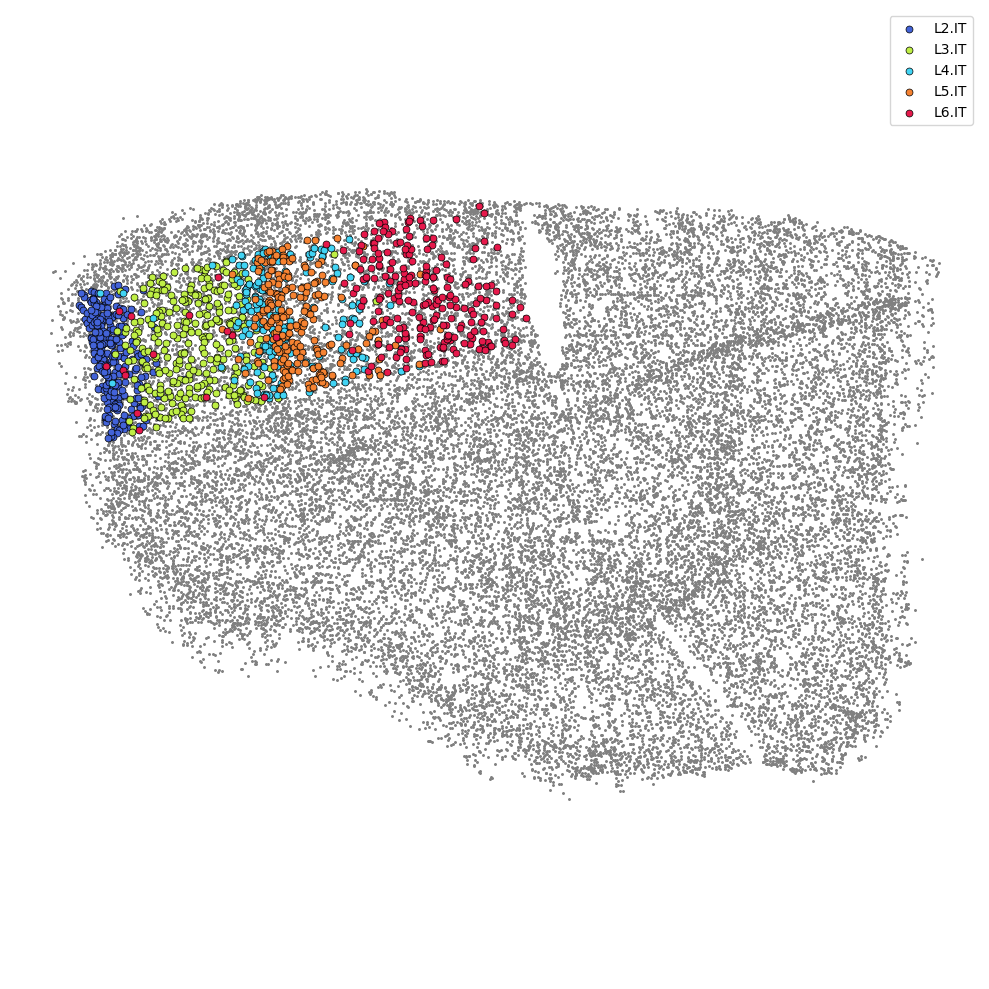

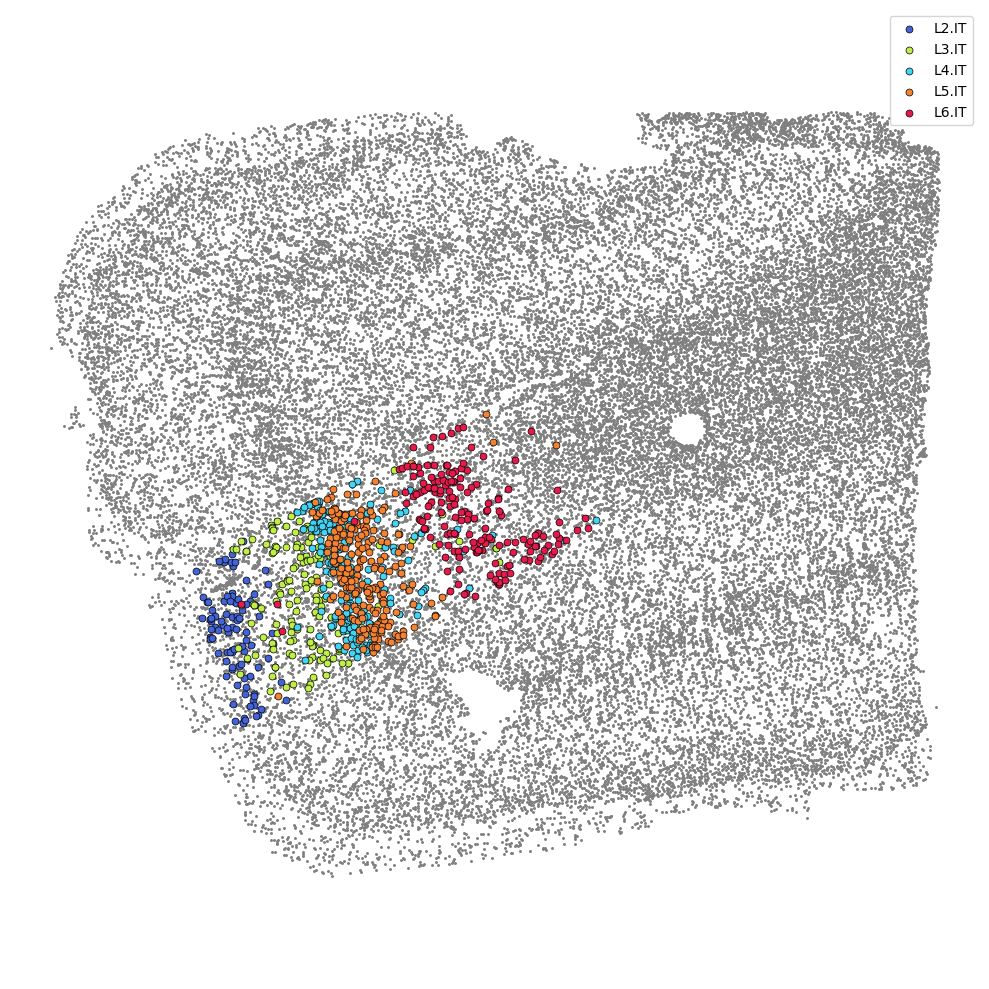

In [25]:
#Coumn Example
cmap = ['#4363d8', '#bfef45', #L2, L3, 
    '#42d4f4', # L4 '#FF6347','#FF6347','#FF6347', #L4.5,
    '#f58231', # L5
      '#e6194B', #L6CT, L6, L6Car3, L6b
       ]

plot_cluster_name_scdata(C5_col,cmap,clusters=['L2.IT','L3.IT','L4.IT','L5.IT', 'L6.IT'],transpose=1,flipx=1,flipy=1,sbig=100,small=5);
plt.savefig('Figures/F2ACTL.png', dpi=300, bbox_inches='tight')
plot_cluster_name_scdata(H8_col,cmap,clusters=['L2.IT','L3.IT','L4.IT','L5.IT', 'L6.IT'],transpose=1,flipx=1,flipy=1,sbig=100,small=5);
plt.savefig('Figures/F2AHD.png', dpi=300, bbox_inches='tight')

In [26]:
##################################################
#### FIGURE 2C
##################################################

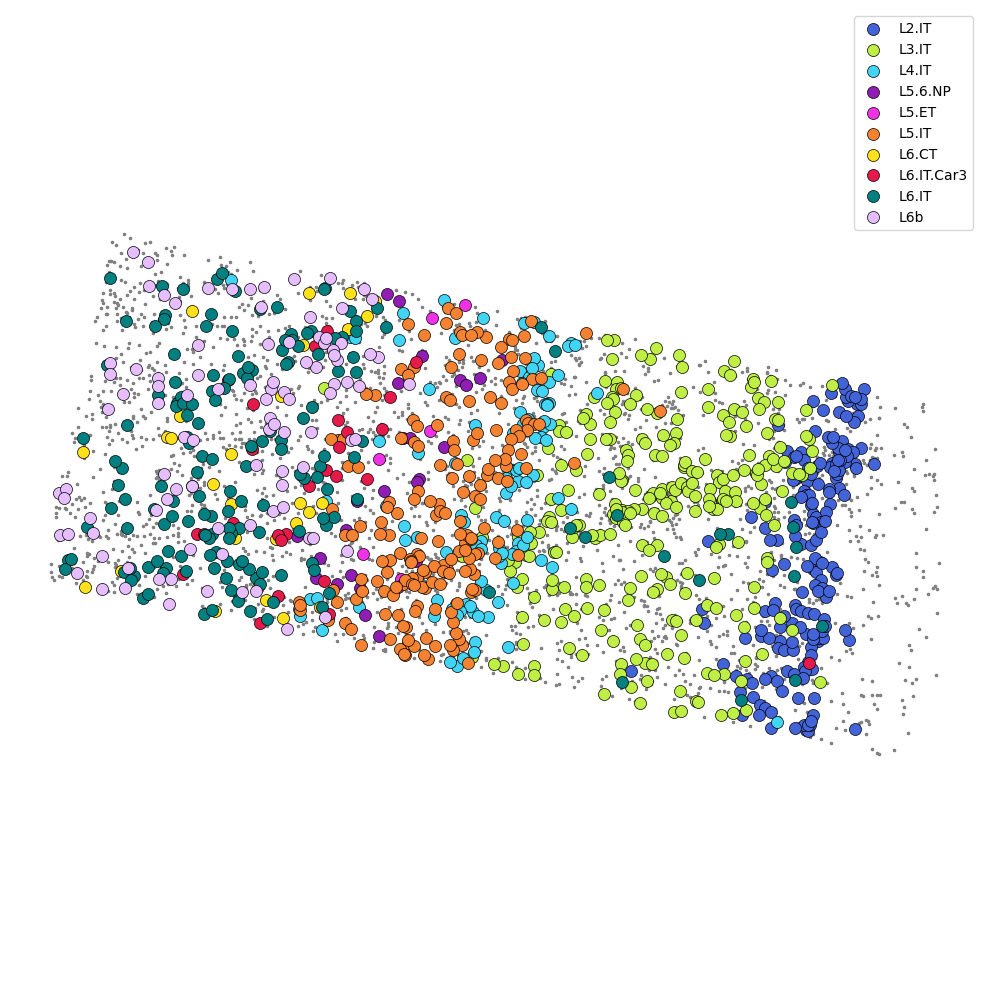

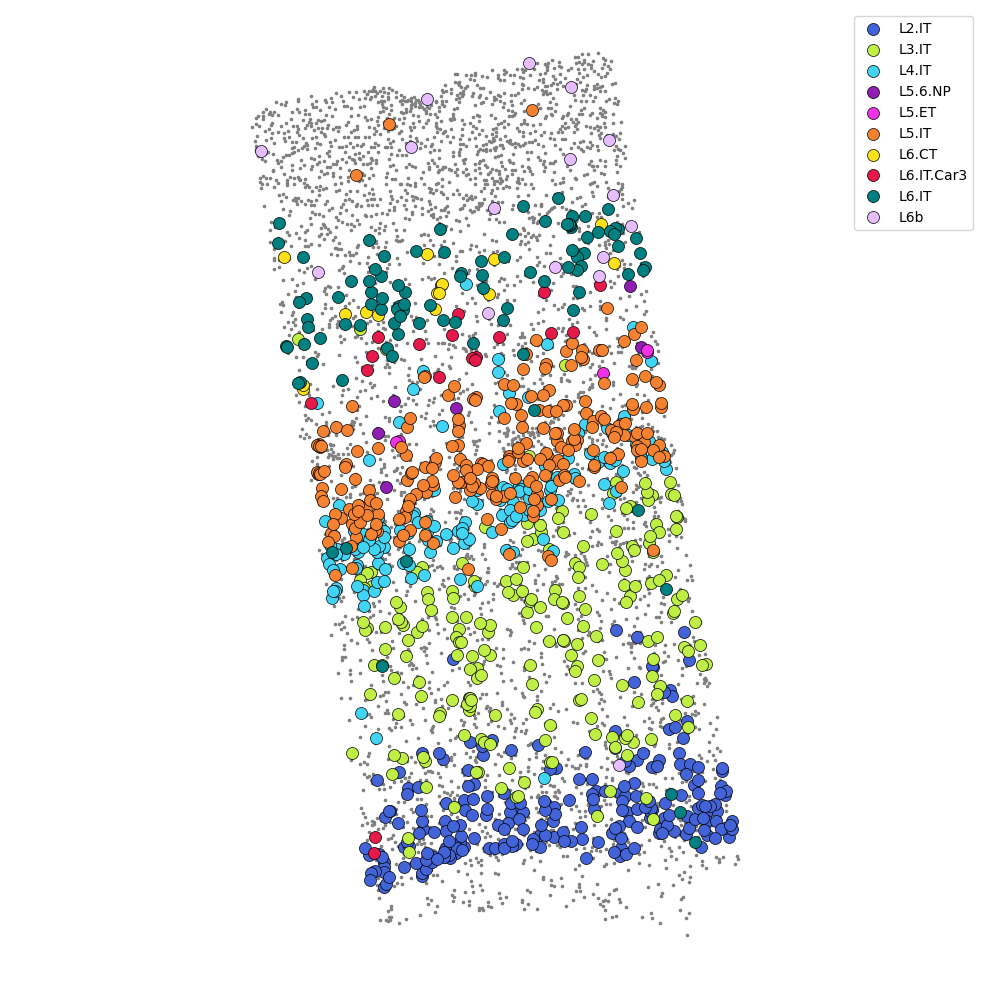

In [26]:
#Excitatory Neuron column
cmap = ['#4363d8', '#bfef45', #L2, L3, 
    '#42d4f4', # L4 '#FF6347','#FF6347','#FF6347', #L4.5,
    '#911eb4', '#f032e6','#f58231', #L56NP, L5ET, L5
    '#ffe119',   '#e6194B','#008080', '#e6beff', #L6CT, L6, L6Car3, L6b 
       ]

plot_cluster_name_scdata(C5_p_1,cmap,clusters=['L2.IT','L3.IT','L4.IT','L5.6.NP','L5.ET','L5.IT', 'L6.CT', 'L6.IT.Car3','L6.IT', 'L6b'],transpose=1,flipx=1,flipy=1,sbig=300,small=10);
plt.savefig('Figures/F2CCTL.png', dpi=300, bbox_inches='tight')
plot_cluster_name_scdata(H8_p_1,cmap,clusters=['L2.IT','L3.IT','L4.IT','L5.6.NP','L5.ET','L5.IT', 'L6.CT', 'L6.IT.Car3','L6.IT', 'L6b'],transpose=1,flipx=1,flipy=1,sbig=300,small=10);
plt.savefig('Figures/F2CHD.png', dpi=300, bbox_inches='tight')

In [27]:
##################################################
#### FIGURE 2E
##################################################

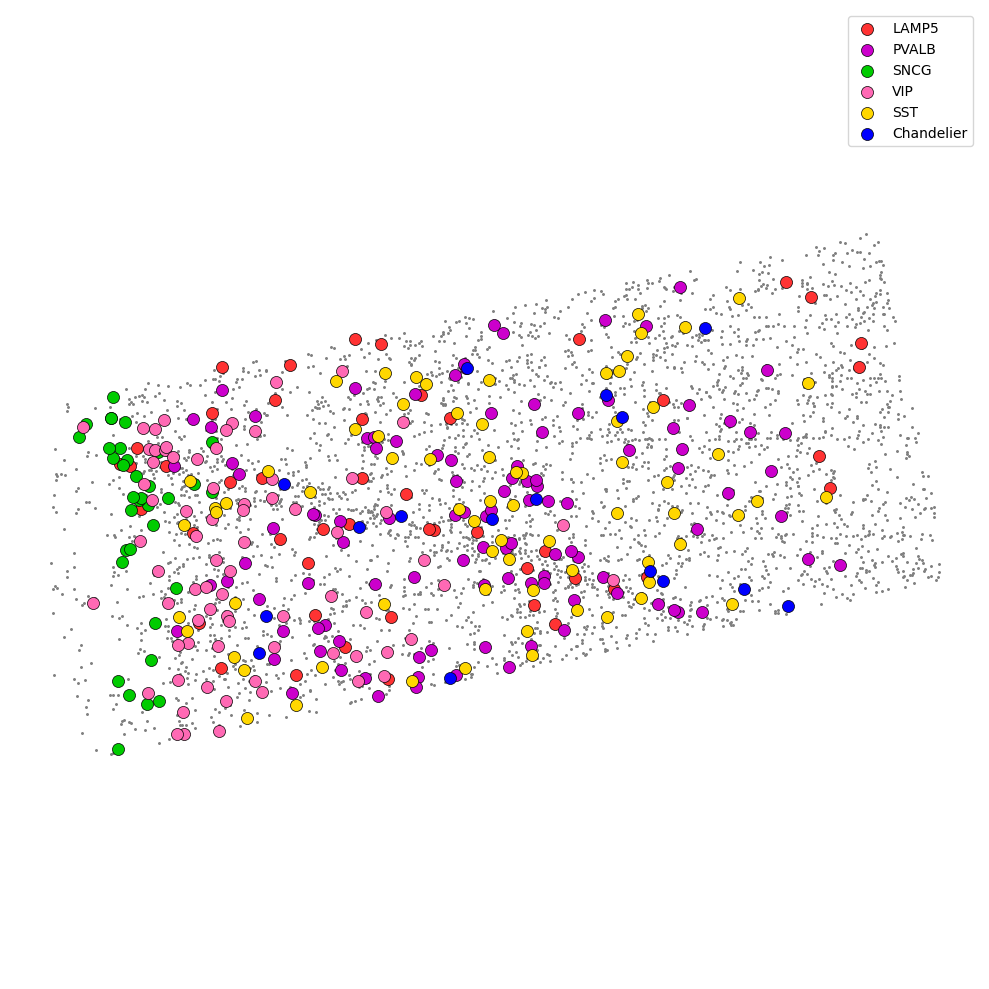

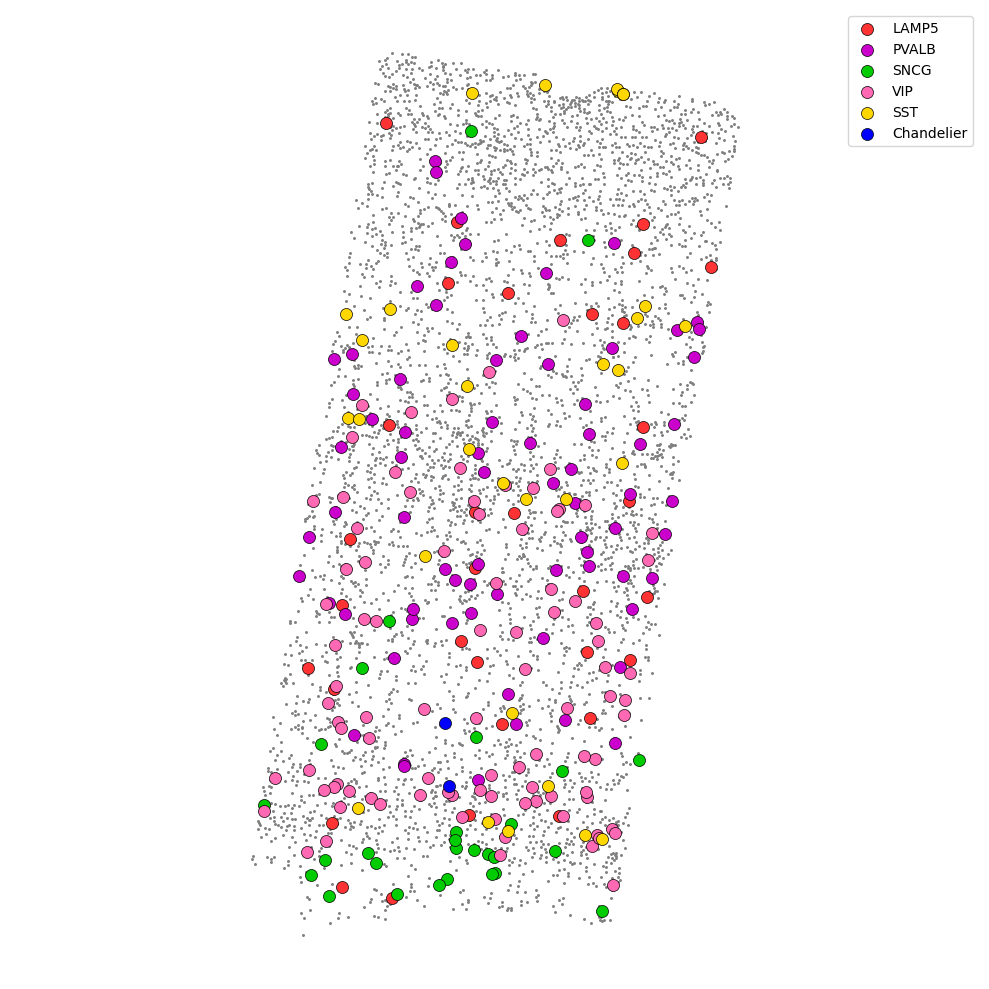

In [28]:
#Inhibitory Neuron column
cmap =['#ff3333',  '#cc00cc',  #LAMP PVALB
    '#00cc00', '#FF69B4',  '#FFD700',  #SNCG, VIP
    '#0000ff' # SST, Chandelier 
      ]

plot_cluster_name_scdata(C5_p_1,cmap,clusters=['LAMP5','PVALB','SNCG',  'VIP','SST','Chandelier',],transpose=1,flipx=1,flipy=-1,sbig=300,small=5);
plt.savefig('Figures/F2ECTL.png', dpi=300, bbox_inches='tight')
plot_cluster_name_scdata(H8_p_1,cmap,clusters=['LAMP5','PVALB','SNCG',  'VIP','SST','Chandelier',],transpose=1,flipx=1,flipy=-1,sbig=300,small=5);
plt.savefig('Figures/F2EHD.png', dpi=300, bbox_inches='tight')

In [29]:
##################################################
#### FIGURE 2I
##################################################

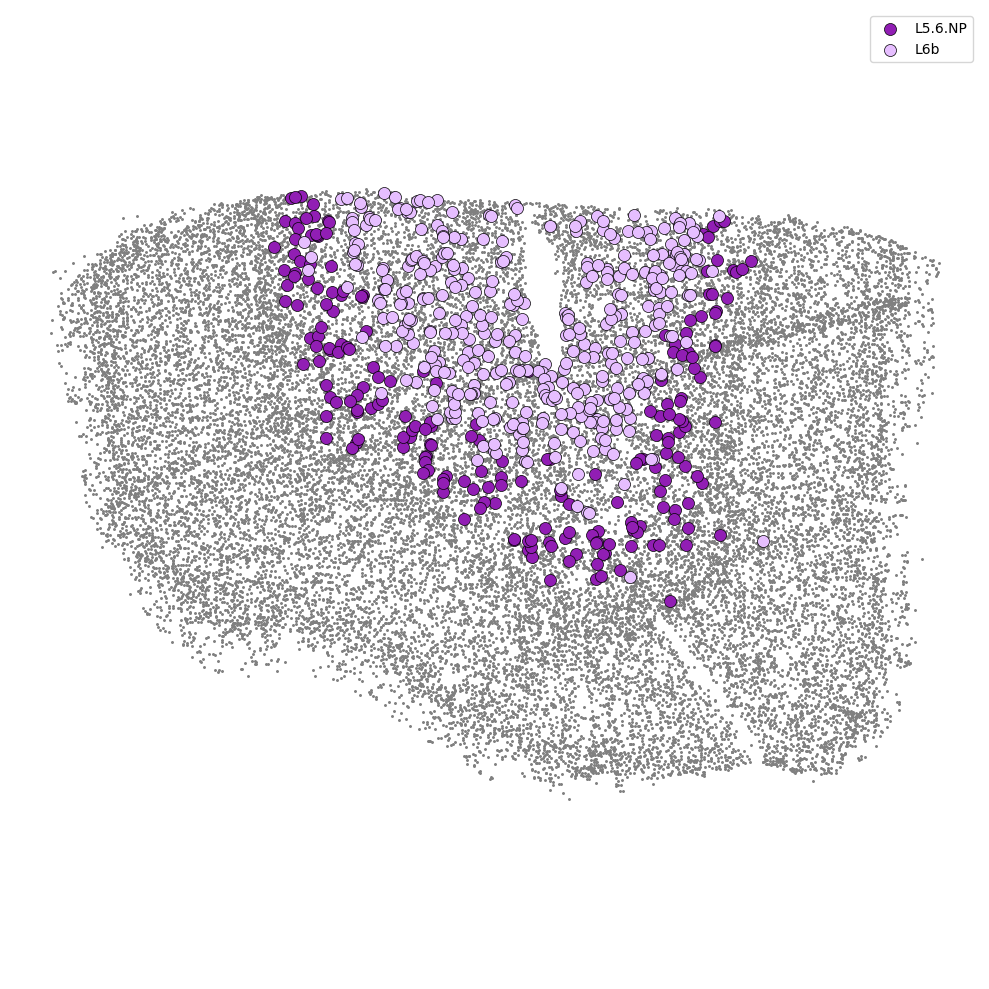

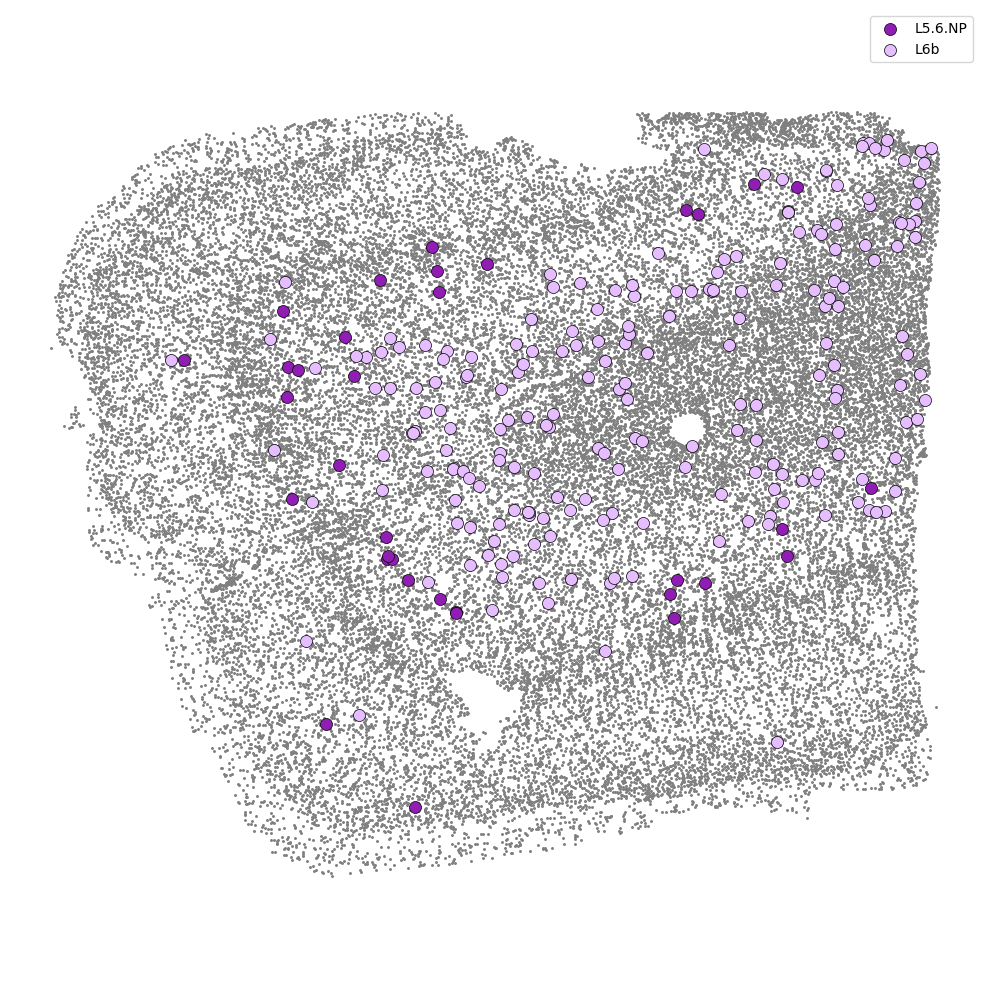

In [30]:
#Excittaory Nuerons Lost
cmap = [ "#911eb4", #L56NP
    '#e6beff', #L6b
       ]

plot_cluster_name_scdata(C5,cmap,clusters=['L5.6.NP', 'L6b'],transpose=1,flipx=1,flipy=1,sbig=300,small=5);
plt.savefig('Figures/F2ICTL.png', dpi=300, bbox_inches='tight')

plot_cluster_name_scdata(H8,cmap,clusters=['L5.6.NP', 'L6b'],transpose=1,flipx=1,flipy=1,sbig=300,small=5);
plt.savefig('Figures/F2IHD.png', dpi=300, bbox_inches='tight')


In [31]:
##################################################
#### FIGURE 2J
##################################################

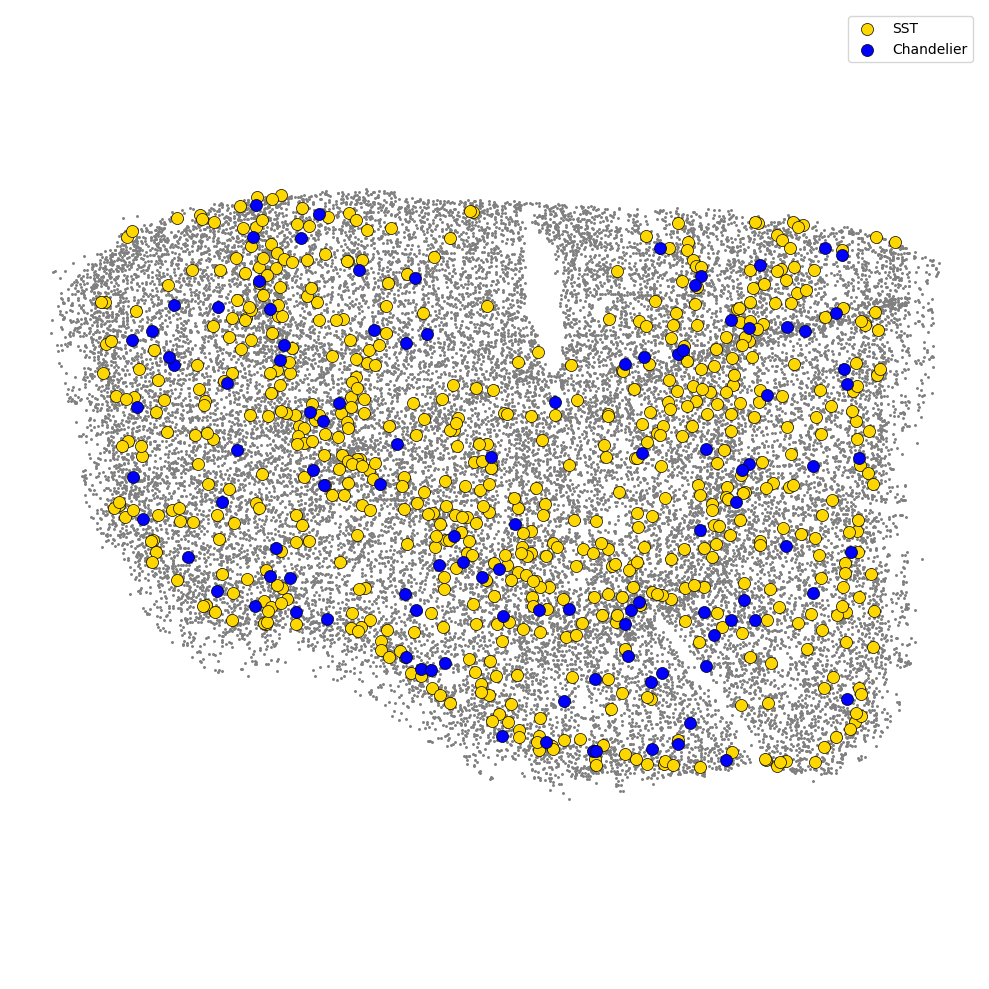

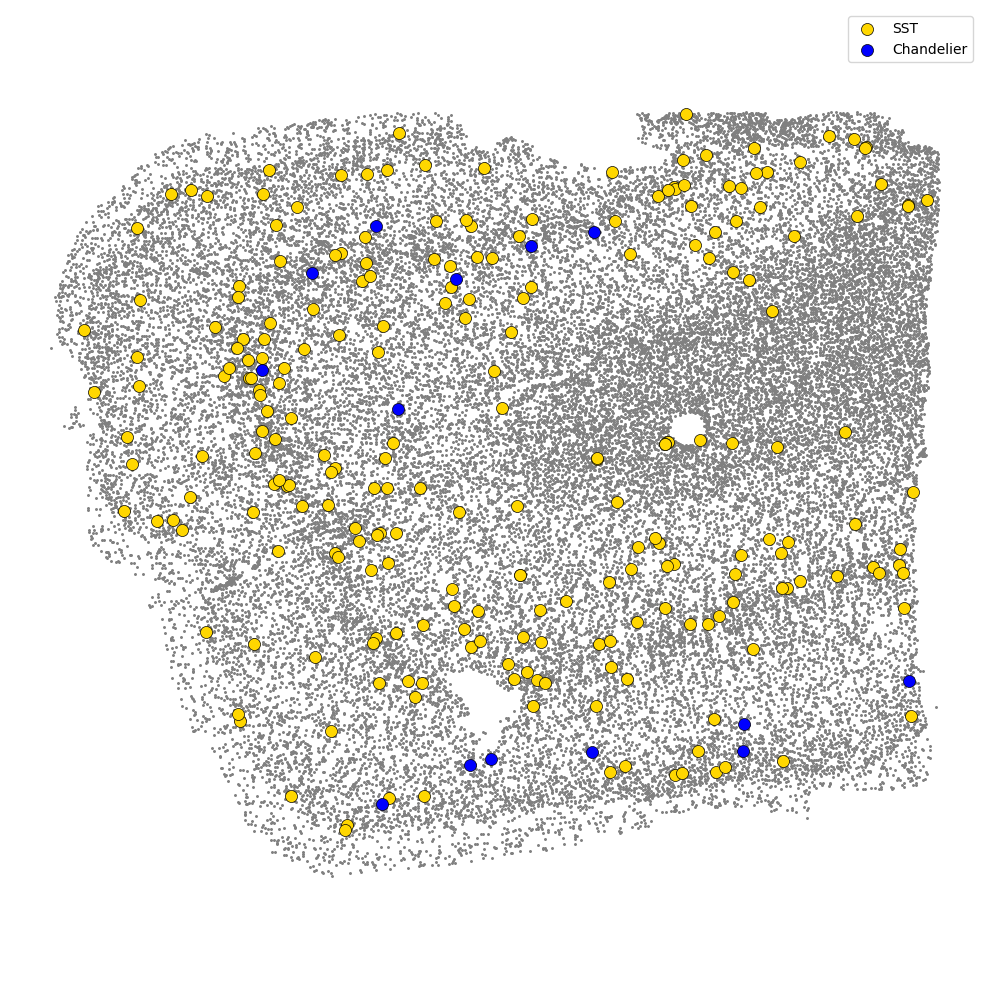

In [32]:
#Inhibitory Nuerons Lost
cmap =['#FFD700',  #SNCG, 
     '#0000ff' # SST, Chandelier
      ]

plot_cluster_name_scdata(C5,cmap,clusters=['SST','Chandelier'],transpose=1,flipx=1,flipy=1,sbig=300,small=5);
plt.savefig('Figures/F2JCTL.png', dpi=300, bbox_inches='tight')
plot_cluster_name_scdata(H8,cmap,clusters=[  'SST','Chandelier'],transpose=1,flipx=1,flipy=1,sbig=300,small=5);
plt.savefig('Figures/F2JHDL.png', dpi=300, bbox_inches='tight')

### Quantification of cell types per layer. Saved quantification at "cell_counts_by_layer.csv"

In [33]:
##################################################
#### SUPPLEMENTARY FIGURE 8A: Spatial Projection of layer mask
##################################################

In [34]:
adata_188=sc.read_h5ad('../W_Data_Short/adata_short.h5ad')

In [35]:
adata_188

AnnData object with n_obs × n_vars = 428973 × 188
    obs: 'volm', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'leiden', 'vol_nuc', 'sample', 'HD', 'patient', 'total_counts_oag', 'CAG_level', 'HTT_number', 'batch', 'cluster_names', 'cluster_general', 'Expansion', 'Agg', 'Agg_bright', 'Agg_vol', 'Agg_x', 'Agg_y', 'Agg_z', 'Agg_dist', 'BBData'
    var: 'n_cells_by_counts-0-0-0', 'mean_counts-0-0-0', 'log1p_mean_counts-0-0-0', 'pct_dropout_by_counts-0-0-0', 'total_counts-0-0-0', 'log1p_total_counts-0-0-0', 'n_cells_by_counts-1-0-0', 'mean_counts-1-0-0', 'log1p_mean_counts-1-0-0', 'pct_dropout_by_counts-1-0-0', 'total_counts-1-0-0', 'log1p_total_counts-1-0-0', 'n_cells_by_counts-2-0-0', 'mean_counts-2-0-0', 'log1p_mean_counts-2-0-0', 'pct_dropout_by_counts-2-0-0', 'total_counts-2-0-0', 'log1p_total_counts-2-0-0', 'n_cells_by_counts-3-0-0', 'mean_counts-3-0-0', 'log1p_mean_counts-3-0-0', 'pct_dropout_by_counts-3-0-0', 'total_counts-3-0-0', 'log1p_to

In [36]:
upatient= adata_188.obs['patient'].unique()

In [37]:
cmap = [
    '#4363d8', '#bfef45', #L2, L3, 
    '#42d4f4', # L4 '#FF6347','#FF6347','#FF6347', #L4.5,
    '#911eb4', '#f032e6','#f58231', #L56NP, L5ET, L5
    '#ffe119',   '#e6194B','#008080', '#e6beff', #L6CT, L6, L6Car3, L6b
]

colors_light = ['#4363d8', '#bfef45', '#42d4f4','#f58231','#e6194B','#D3D3D3','#D3D3D3']
layers = ['L2.IT','L3.IT','L4.IT','L5.IT','L6.IT','Astro.WM','Astro.P',]

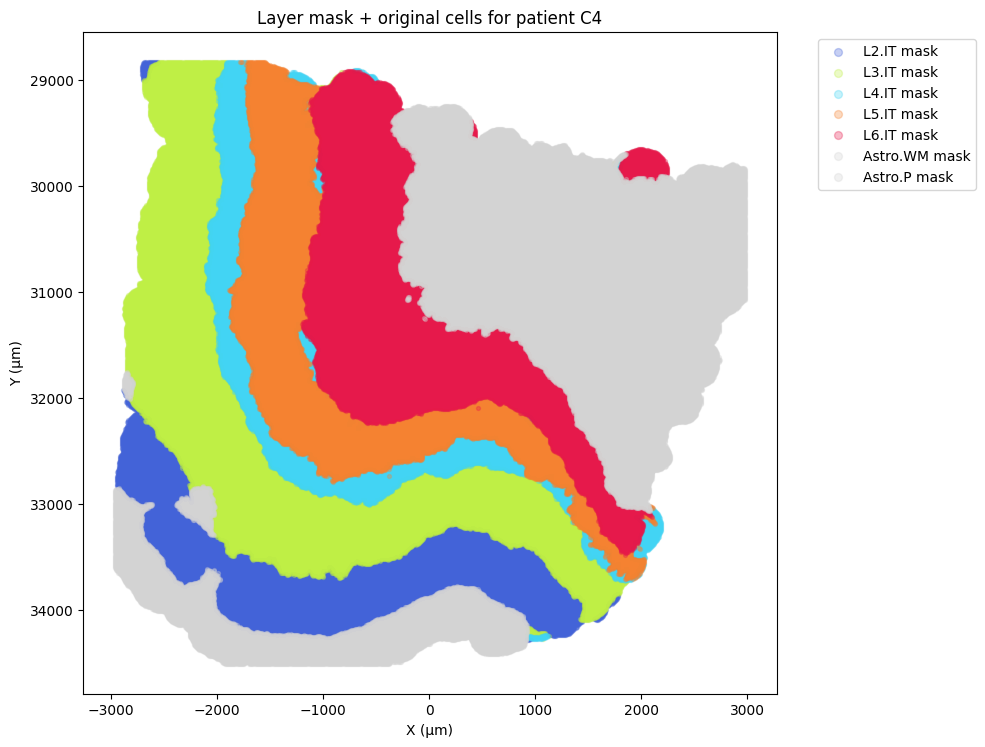

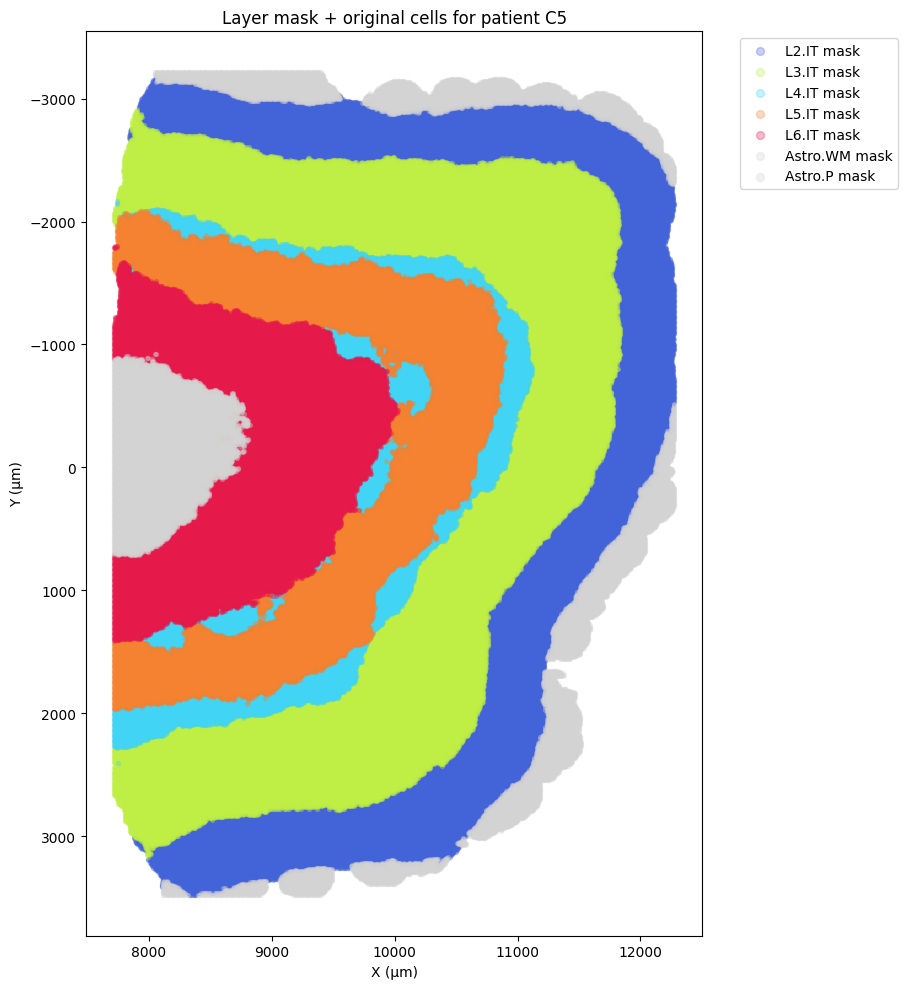

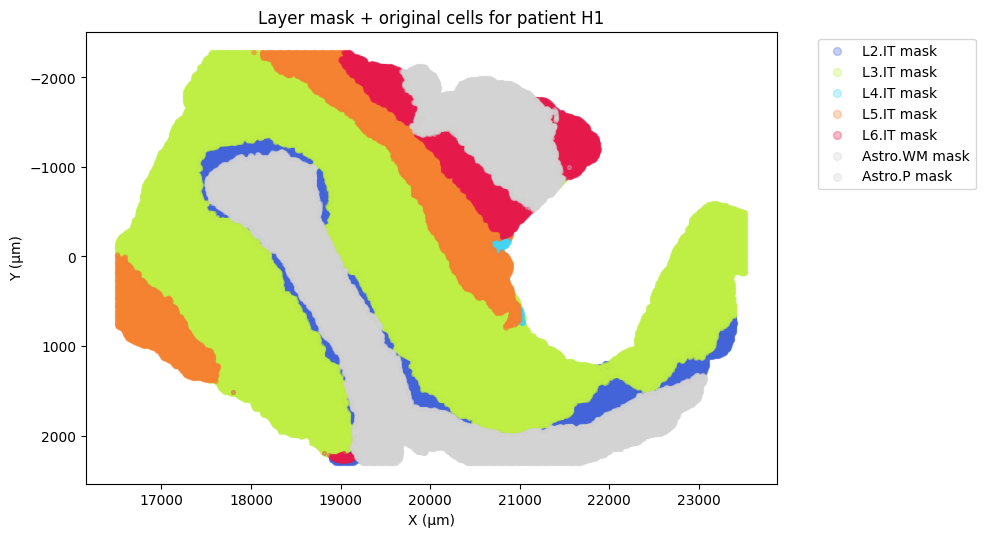

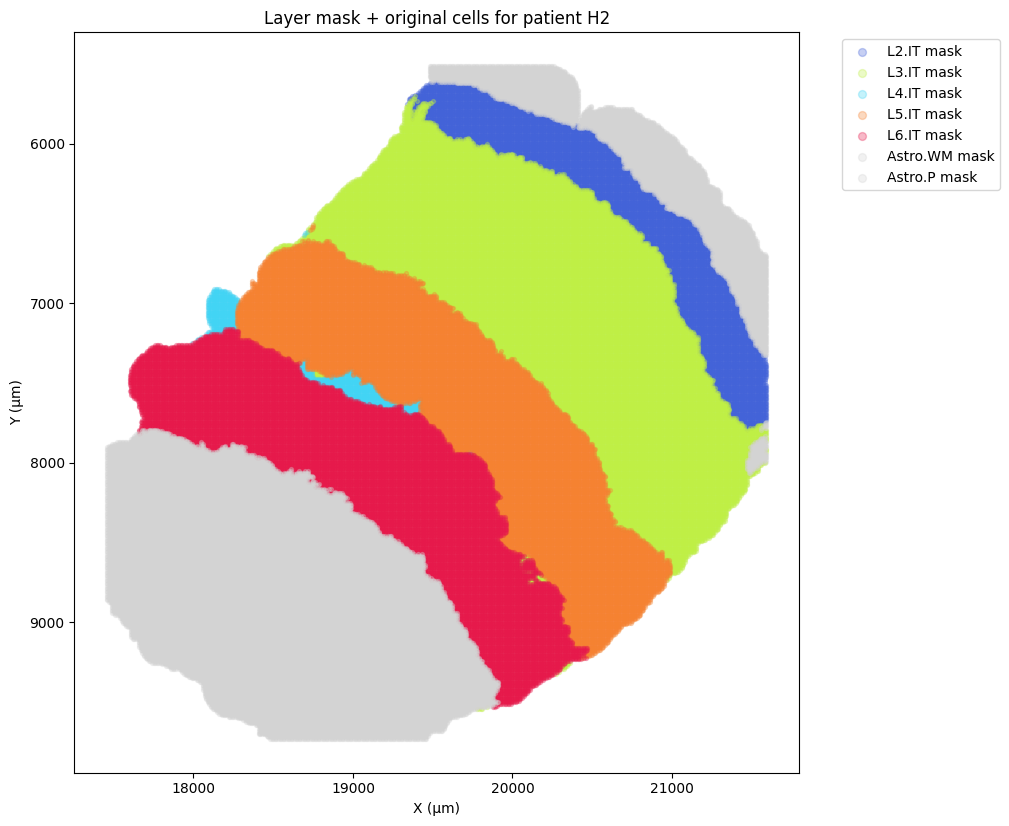

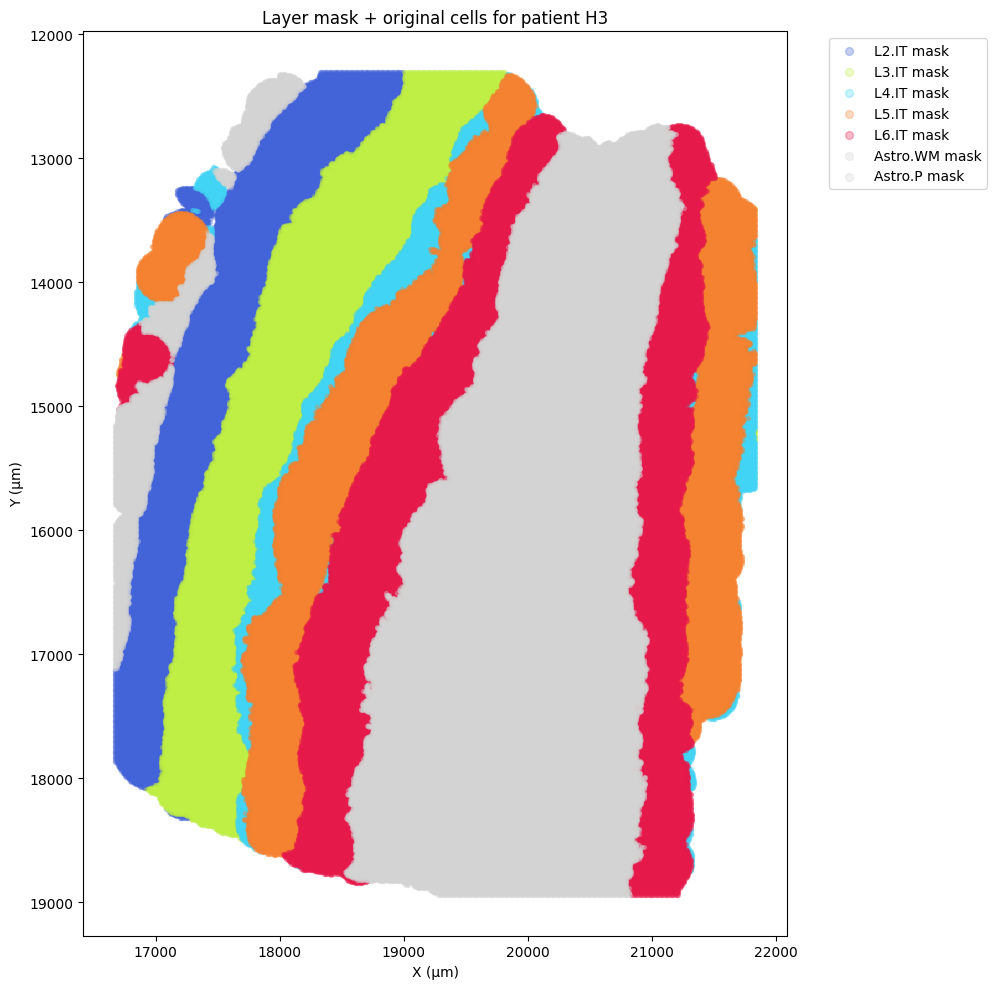

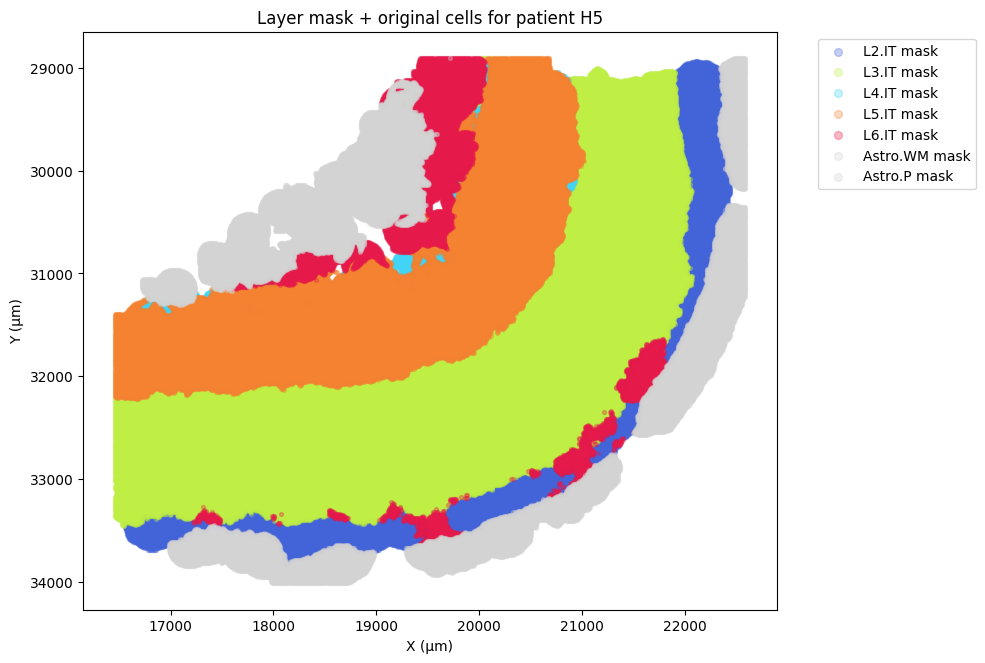

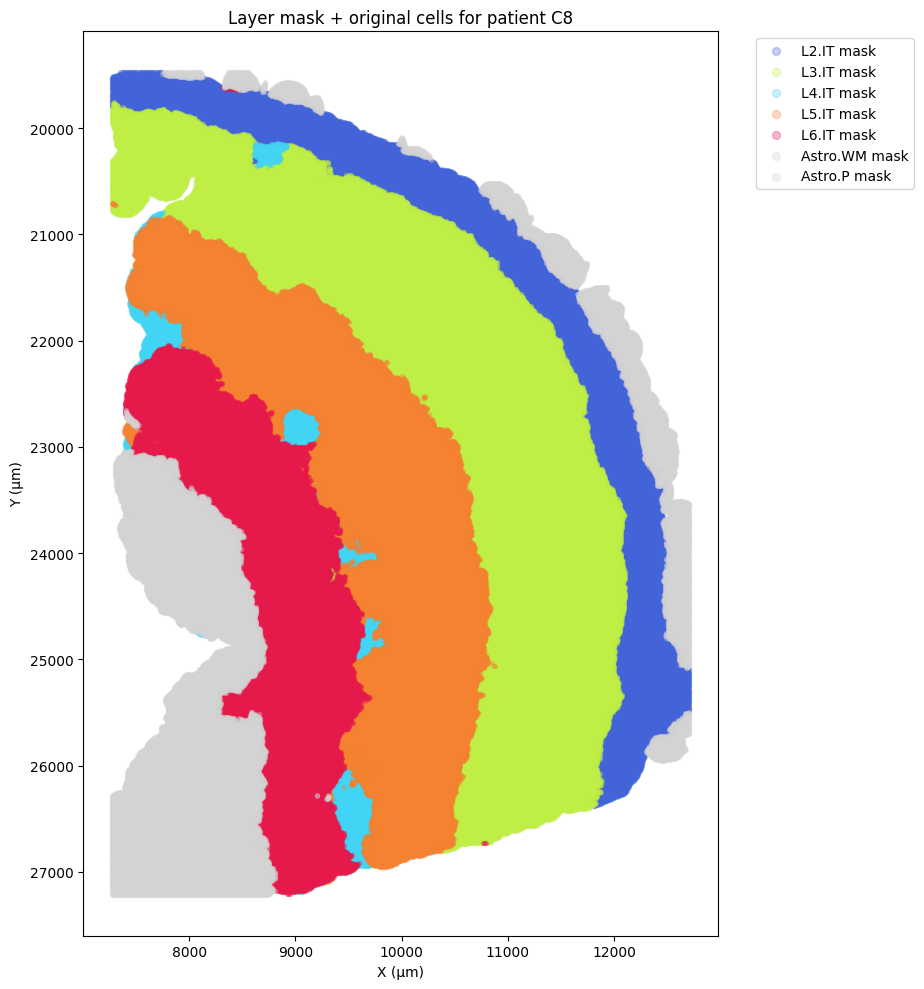

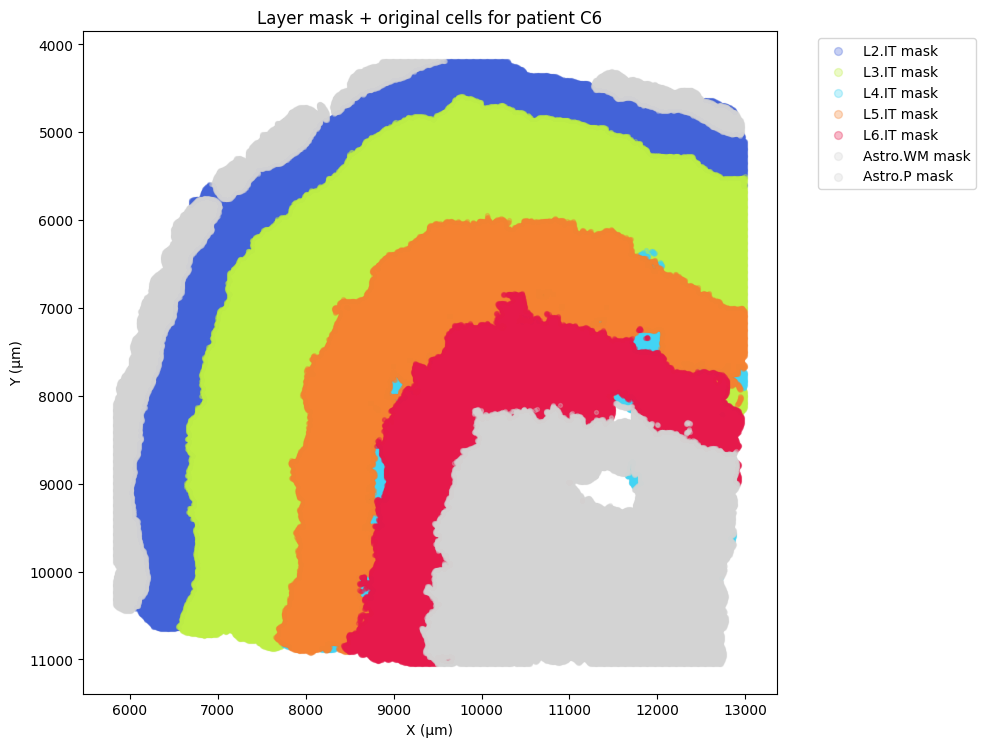

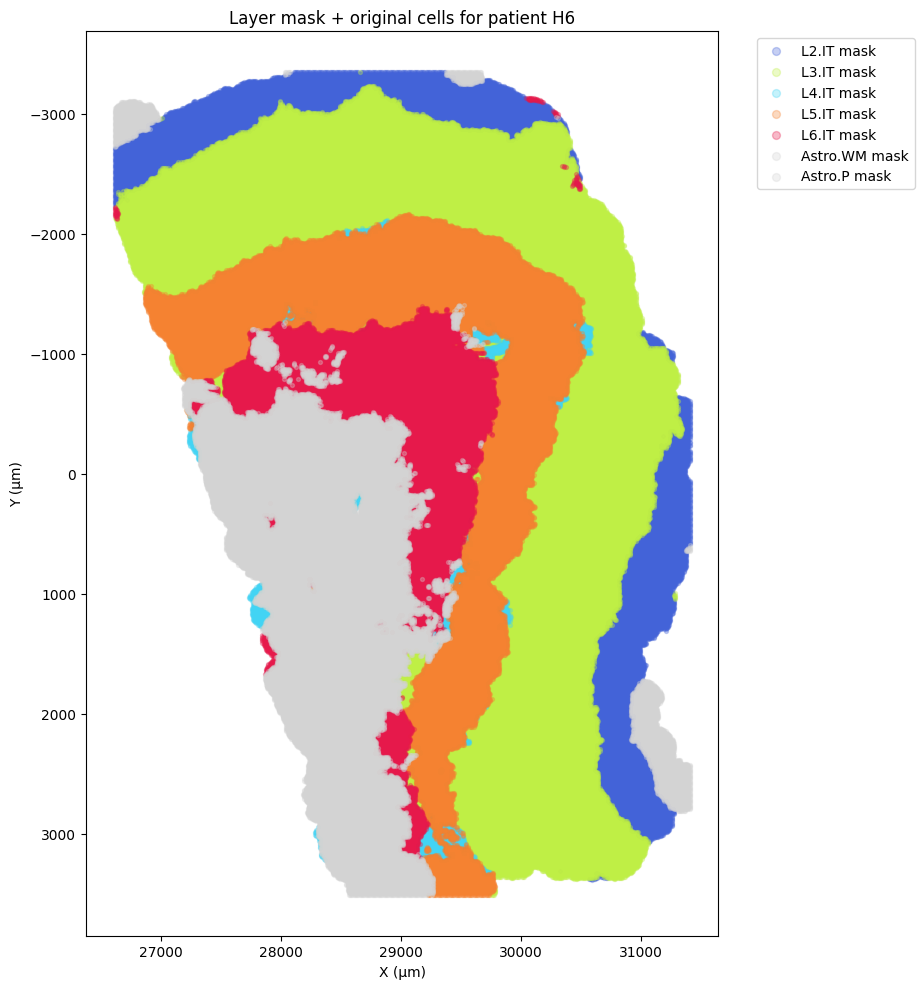

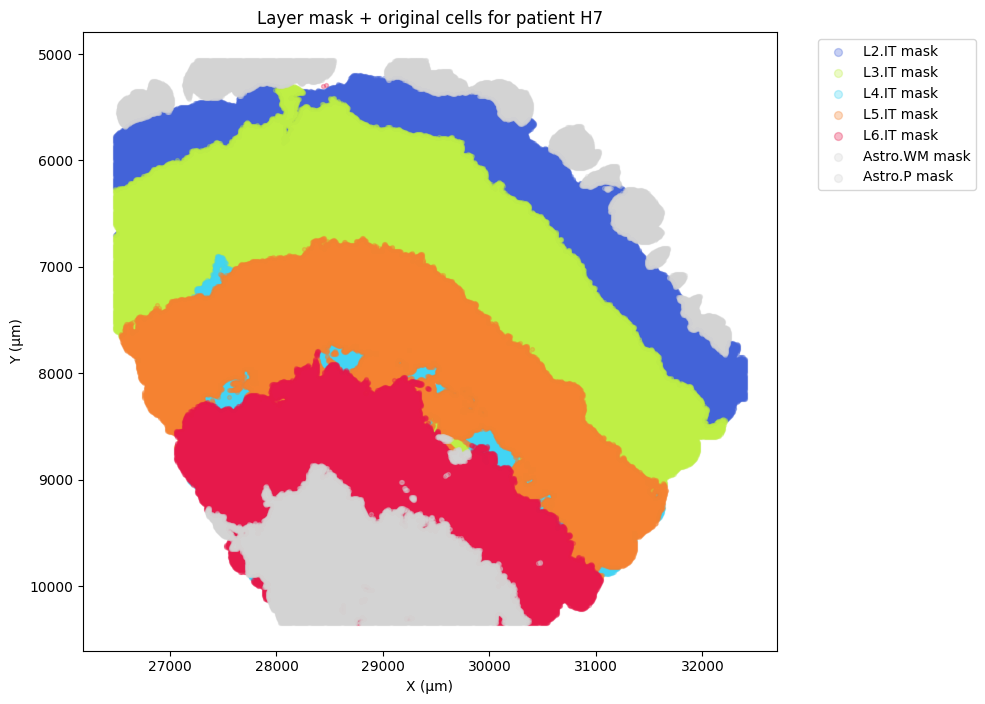

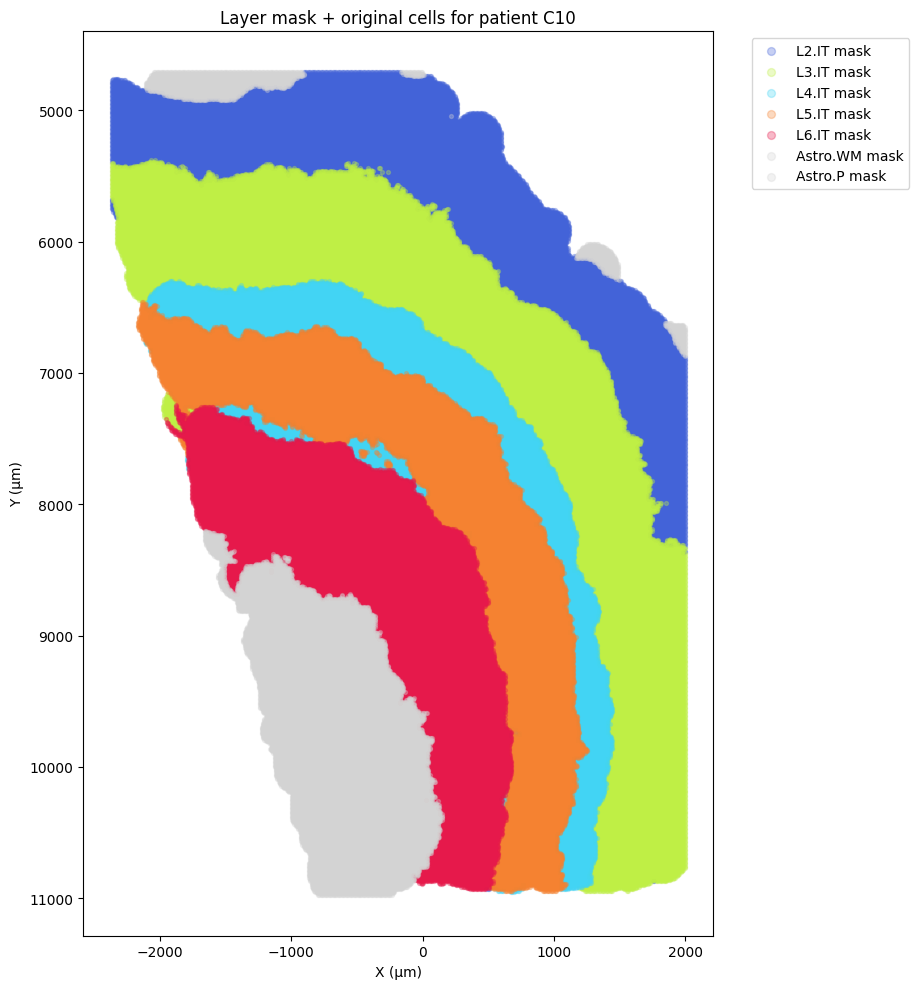

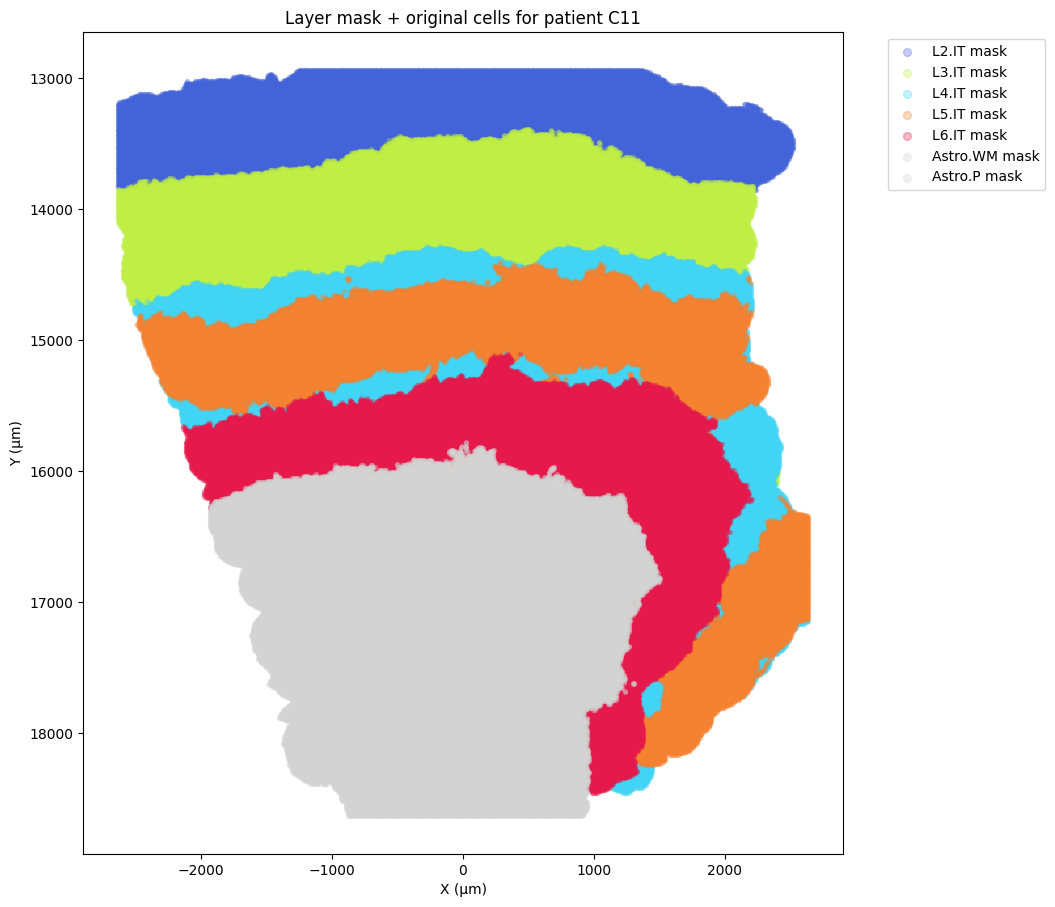

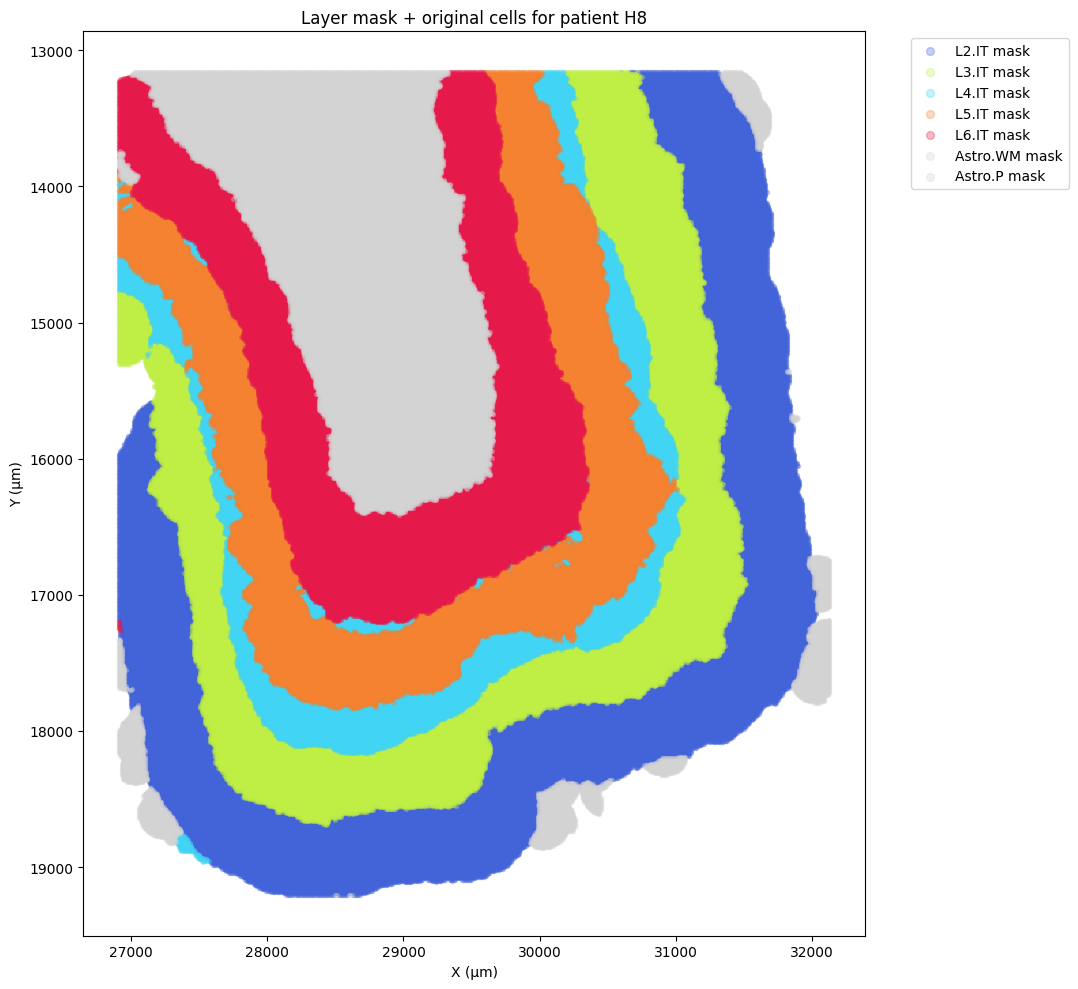

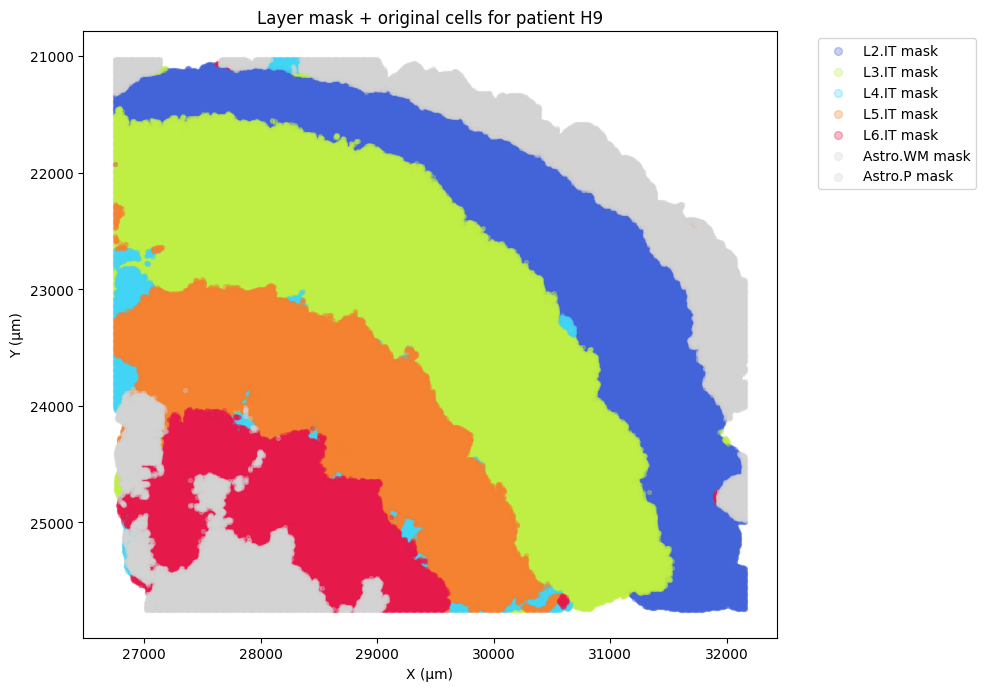

In [38]:
for pt in upatient:
    scdata_ = adata_all[adata_all.obs['patient']==pt]
    
    X = scdata_.obsm['X_spatial'].copy()
    cluster_names = np.array(scdata_.obs['cluster_names'])
    iscelltype = np.in1d(cluster_names, layers)
    X = X[iscelltype]
    cluster_names = cluster_names[iscelltype]
    
    m = np.min(X,axis=0)
    M = np.max(X,axis=0)
    res = 10  # resolution in microns
    Xp = np.array([(x_,y_) for x_ in np.arange(m[0],M[0],res)
                            for y_ in np.arange(m[1],M[1],res)])
    
    tree = KDTree(X)
    dd, nn = tree.query(Xp, k=100)  # look at 100 neighbors
    cls = cluster_names[nn]
    cls[dd>200] = ''  # ignore points farther than 200um
    
    cts_per_layer = np.array([np.sum(cls==l,axis=-1) for l in layers]).T
    layersF = np.argmax(cts_per_layer,axis=-1)
    ncells = np.sum(cts_per_layer,axis=1)
    
    valid_mask = ncells > 1
    Xpf = Xp[valid_mask]
    layersF = layersF[valid_mask]

    # PLOT
    plt.figure(figsize=(10, 10))
    for i, layer in enumerate(layers):
        plt.scatter(Xpf[layersF==i,0], Xpf[layersF==i,1],
                    s=8, c=colors_light[i], alpha=0.3, label=f'{layer} mask')

    plt.title(f"Layer mask + original cells for patient {pt}")
    plt.xlabel('X (µm)')
    plt.ylabel('Y (µm)')
    plt.gca().invert_yaxis()
    plt.gca().set_aspect('equal') 
    plt.legend(markerscale=2, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

In [39]:
mean_area_by_layer = {}

for patient, sections in patient_sections.items():
    all_section_area = {layer: [] for layer in layers}
    
    for scdata_ in sections:
        X = scdata_.obsm['X_spatial'].copy()
        cluster_names = np.array(scdata_.obs['cluster_names'])
        iscelltype = np.in1d(cluster_names, layers)
        X = X[iscelltype]
        cluster_names = cluster_names[iscelltype]
        
        m, M = np.min(X, axis=0), np.max(X, axis=0)
        res = 10
        Xp = np.array([(x_, y_) for x_ in np.arange(m[0], M[0], res)
                                  for y_ in np.arange(m[1], M[1], res)])
    
        tree = KDTree(X)
        dd, nn = tree.query(Xp, k=100)
        cls = cluster_names[nn]
        cls[dd > 200] = '' 
        
        cts_per_layer = np.array([np.sum(cls == l, axis=-1) for l in layers]).T
        layersF = np.argmax(cts_per_layer, axis=-1)
        ncells = np.sum(cts_per_layer, axis=1)
        
        valid_mask = ncells > 1
        Xpf = Xp[valid_mask]
        layersF = layersF[valid_mask]

        area_counts = {}
        for i, layer in enumerate(layers):
            area_counts[layer] = np.sum(layersF == i) * (res ** 2)
            all_section_area[layer].append(area_counts[layer])

            cell_counts_by_layer = {layer: {} for layer in layers}
            
            for i, layer in enumerate(layers):
                layer_mask = layersF == i
                if not np.any(layer_mask):
                    continue
    
                layer_coords = Xpf[layer_mask]
    
                full_X = scdata_.obsm['X_spatial'].copy()
                full_clusters = np.array(scdata_.obs['cluster_names'])
    
                tree_layer = KDTree(layer_coords)
                dists, _ = tree_layer.query(full_X, k=1)
    
                within_layer = dists < 50 
                layer_cell_types = full_clusters[within_layer]
    
                layer_counts = pd.Series(layer_cell_types).value_counts().to_dict()
                cell_counts_by_layer[layer] = layer_counts

        if 'celltype_counts_all' not in locals():
            celltype_counts_all = {}

        for layer, cdict in cell_counts_by_layer.items():
            for cell_type, count in cdict.items():
                key = (patient, layer, cell_type)
                celltype_counts_all.setdefault(key, []).append(count)
    
    mean_counts = {layer: np.mean(all_section_area[layer]) for layer in layers}
    mean_area_by_layer[patient] = pd.DataFrame({
        'Layer': layers,
        'Mean Area': [mean_counts[layer] for layer in layers]
    })

In [40]:
rows = []
for (patient, layer, cell_type), counts in celltype_counts_all.items():
    rows.append({
        'Patient': patient,
        'Layer': layer,
        'Cell Type': cell_type,
        'Mean Count': np.mean(counts),
        'Total Count': np.sum(counts),
        'N Sections': len(counts)
    })

counts_by_layer_celltype = pd.DataFrame(rows)
counts_by_layer_celltype.to_csv("cell_counts_by_layer.csv", index=False)

### Quantification of HTT expression per cell cluster:

In [41]:
adata_188=sc.read_h5ad('../W_Data_Short/adata_short.h5ad')

In [42]:
adata_188_f=adata_188[adata_188.obs['cluster_names']!=''].copy()

In [43]:
CTL=adata_188_f[adata_188_f.obs['HD']==False].copy()
HD=adata_188_f[adata_188_f.obs['HD']==True].copy()
CTL_Neuron = CTL[CTL.obs['cluster_general'].isin(['Inhibitory Neurons', 'Excitatory Neurons'])].copy()

In [44]:
Exc_sorted_categories=['Excitatory Neurons', 'Inhibitory Neurons', 'OPC', 'Astrocytes', 'Oligodendrocytes', 'Microglia', 'Endothelial', 'VLMC'] 
Neurons_sorted_categories=["L2.IT", "L3.IT", "L4.IT",'L5.IT', 'L5.ET', "L5.6.NP", 'L6.IT', "L6.CT",'L6.IT.Car3','L6b',"Chandelier","LAMP5", "PVALB", "SNCG", "SST",'VIP',]

In [45]:
##################################################
#### FIGURE 2J: HTT Expression per major cluster
##################################################

In [47]:
CTL.obs['total_counts'] = CTL.obsm['X_raw'].sum(axis=1)

In [48]:
CTL.X = CTL.obsm["X_raw"].copy()
sc.pp.calculate_qc_metrics(CTL, percent_top=None, inplace=True)
sc.pp.normalize_total(CTL, target_sum=np.median(CTL.obs["total_counts"]))
sc.pp.log1p(CTL)

/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/Users/Olatz/anaconda3/envs/napari/lib/python3.9/site-packages/seaborn/categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


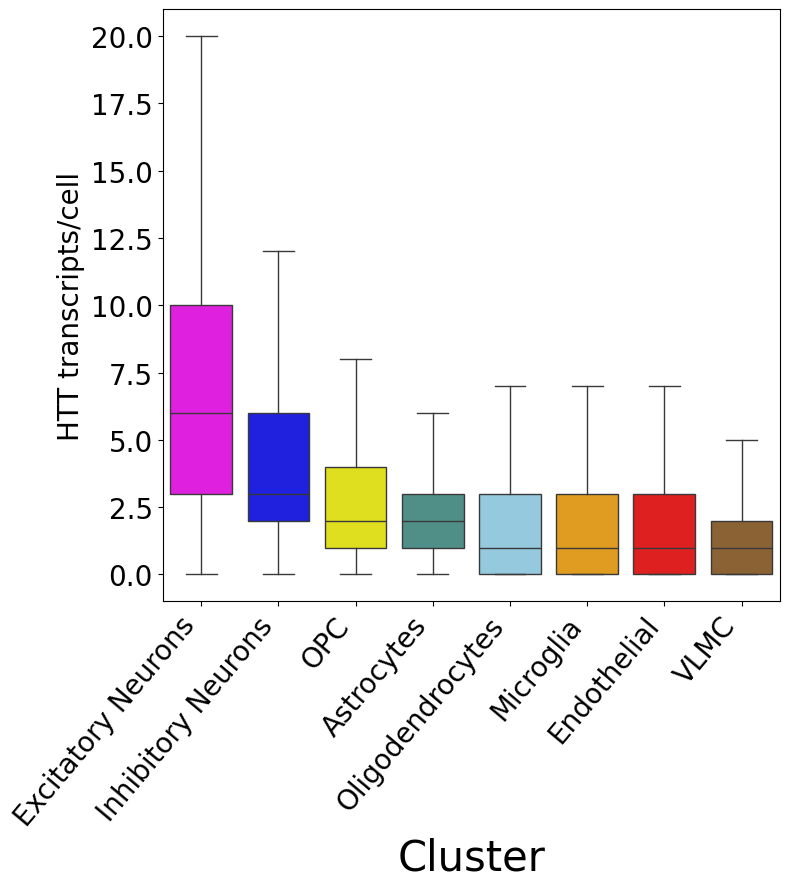

In [49]:
Exc_sorted_categories=['Excitatory Neurons', 'Inhibitory Neurons', 'OPC', 'Astrocytes', 'Oligodendrocytes', 'Microglia', 'Endothelial', 'VLMC'] 
cmap = ['#FF00FF', '#0000ff','yellow', '#469990','#87CEEB','orange','red','#9A6324',]

ign = CTL.var.index.get_loc('HTT')

x_data = CTL.obs['cluster_general']
y_data = (CTL.obsm['X_raw'][:, ign])

plt.figure(figsize=(8, 9))
sns.boxplot(x=x_data, y=y_data,order=Exc_sorted_categories, palette=cmap, showfliers=False, linewidth=1, color='white' )

#plt.title(f'HTT expression in CTL', fontsize=20)
plt.yticks( fontsize=20) 
plt.xticks(rotation=50, ha='right', fontsize=20) 
plt.xlabel('Cluster', fontsize=30)
plt.ylabel('HTT transcripts/cell', fontsize=20)
#plt.ylim(-2,32)
plt.grid(False)
plt.tight_layout()
plt.savefig('Figures/F2K.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [50]:
raw_HTT_clusterg = pd.DataFrame({
    'cluster': CTL.obs['cluster_general'],
    'raw_HTT': CTL.obsm['X_raw'][:, ign]
})

groups = [raw_HTT_clusterg.loc[raw_HTT_clusterg['cluster'] == c, 'raw_HTT'].values 
          for c in Exc_sorted_categories]

f_stat, p_val = stats.f_oneway(*groups) 

print(f"ANOVA F = {f_stat:.3f}, p = {p_val:.3e}")

ANOVA F = 8582.577, p = 0.000e+00


In [51]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=raw_HTT_clusterg['raw_HTT'],
                          groups=raw_HTT_clusterg['cluster'],
                          alpha=0.05)

print(tukey)

            Multiple Comparison of Means - Tukey HSD, FWER=0.05             
      group1             group2       meandiff p-adj   lower   upper  reject
----------------------------------------------------------------------------
        Astrocytes        Endothelial   0.3848    0.0  0.2695  0.5001   True
        Astrocytes Excitatory Neurons   5.0114    0.0  4.9221  5.1006   True
        Astrocytes Inhibitory Neurons   2.1098    0.0  1.9968  2.2229   True
        Astrocytes          Microglia   0.1044 0.1493 -0.0165  0.2253  False
        Astrocytes                OPC   0.6786    0.0  0.5309  0.8263   True
        Astrocytes   Oligodendrocytes   0.0293 0.9682 -0.0559  0.1145  False
        Astrocytes               VLMC  -0.3547    0.0 -0.4977 -0.2118   True
       Endothelial Excitatory Neurons   4.6266    0.0  4.5221  4.7311   True
       Endothelial Inhibitory Neurons    1.725    0.0  1.5995  1.8505   True
       Endothelial          Microglia  -0.2804    0.0  -0.413 -0.1478   True

In [35]:
##################################################
#### FIGURE 2M: HTT Expression vs Cell Loss
##################################################

In [52]:
HTT_neurons = pd.DataFrame({
    'cluster': CTL_Neuron.obs['cluster_names'],
    'HTT': CTL_Neuron.obsm['X_raw'][:, ign]
})
groups = [HTT_neurons.loc[HTT_neurons['cluster'] == c, 'HTT'].values 
          for c in HTT_neurons['cluster'].unique()]
f_stat, p_val = stats.f_oneway(*groups) 
print(f"ANOVA F = {f_stat:.3f}, p = {p_val:.3e}")

ANOVA F = 429.633, p = 0.000e+00


In [53]:
mean_htt_per_cluster = HTT_neurons.groupby('cluster', as_index=False)['HTT'].mean()
mean_htt_per_cluster = mean_htt_per_cluster.sort_values('HTT', ascending=False)

/var/folders/7p/t1dymgvj689ffh7fbygsmbzc0000gp/T/ipykernel_74615/1995930299.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_htt_per_cluster = HTT_neurons.groupby('cluster', as_index=False)['HTT'].mean()


In [54]:
percent_lost_df_neu = {
    'cluster': ['L2.IT', 'L3.IT', 'L5.IT', 'L4.IT', 'L5.ET', 'L5.6.NP', 'L6.IT', 'L6.CT', 'L6.Car3', 'L6b','Chandelier', 'LAMP5', 'PVALB', 'SNCG', 'SST', 'VIP' ],
    'Percent Lost': [38.965629, 7.597639, 21.390964, 44.542414, 9.159061, 84.112792, 24.816347, 42.304075, 2.011352, 53.409478,55.550050,7.380457, 14.008406,  -1.760563,   51.870968, 4.372169 ]
}
percent_lost_df_neu = pd.DataFrame(percent_lost_df_neu)
percent_lost_df_neu.set_index('cluster', inplace=True)

In [55]:
htt_stats_neu = mean_htt_per_cluster.merge(percent_lost_df_neu, on='cluster', how='inner')

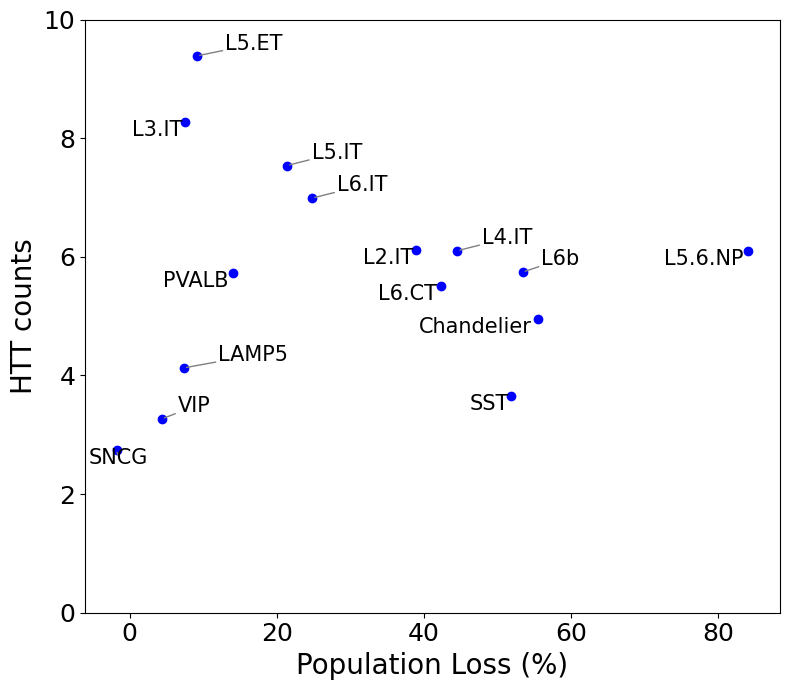

Linear Regression Coefficients:
Slope (Coefficient of Percent Lost): -2.7640512370877767e-05
Intercept: 5.749081198080003
R-squared: 1.3690623024142923e-07
Spearman r: 0.111, p = 0.69


In [56]:
X = htt_stats_neu[['Percent Lost']]
y = htt_stats_neu['HTT']  

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

plt.figure(figsize=(8, 7))
plt.scatter(X, y, color='blue', label='Data')

texts = []
for i, row in htt_stats_neu.iterrows():
    texts.append(plt.text(row['Percent Lost'], row['HTT'], row['cluster'], fontsize=15))
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray'))

r, p = spearmanr(X.values.ravel(), y.values.ravel())

plt.xlabel('Population Loss (%)', size=20)
plt.ylabel('HTT counts', size=20)
plt.yticks(size=18)
plt.xticks(size=18)
plt.ylim(0,10)
plt.title('')
plt.tight_layout()
plt.grid(False)
plt.savefig('Figures/F2L.pdf', dpi=300, bbox_inches='tight')
plt.show()

print(f'Linear Regression Coefficients:')
print(f'Slope (Coefficient of Percent Lost): {model.coef_[0]}')
print(f'Intercept: {model.intercept_}')
print(f'R-squared: {model.score(X, y)}')
print(f"Spearman r: {r:.3f}, p = {p:.2f}")

